# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

### Who

My audience would be e-commerce business leaders, marketing managers, customer experience teams, and customer retention teams.

These stakeholders care about understanding how customers move through the online shopping journey, from browsing and engagement to purchasing behavior, retention risk, and post-purchase satisfaction.

They would use this information to make better decisions about customer engagement, product strategy, delivery experience, satisfaction, loyalty, and retention.

### What

The main point of my data story is that customer behavior should be understood as a journey, not just as isolated sales transactions.

The datasets help show different parts of this journey, including how customers interact with products, how often they purchase, which customers may be at risk of churn, and how transaction-level experiences such as delivery time, discounts, device usage, and customer ratings relate to satisfaction.

This can help the business identify patterns connected to engagement, customer value, loyalty, churn risk, purchase experience, and customer satisfaction.

The overall project is designed around these different stages of the e-commerce customer experience.

### How

I would plan the story around the main stages of the digital customer journey.

I would first introduce the four datasets and explain what part of the journey each one represents: user engagement, customer sales and retention, churn risk, and transaction-level purchase experience.

Then, I would use exploratory analysis and clear visuals to highlight early patterns in each dataset. For example, I could analyze engagement behavior, customer value, churn-related variables, product category performance, delivery experience, and customer satisfaction separately before connecting them into a broader customer journey story.

The goal would not be to analyze everything at once, but to organize the data story in a way that helps the audience understand how each dataset contributes to the overall project.

# 3. Homework - work with your own data

### Project Overview: Digital Customer Journey & E-Commerce Customer Behavior Analysis

This project examines customer behavior across different stages of the e-commerce experience by combining datasets that capture user engagement, purchasing behavior, customer retention, churn risk, and transaction-level purchase experience.

Together, these datasets provide a broader view of how customers move through the digital shopping journey, from early interaction and engagement to purchases, retention outcomes, and post-purchase satisfaction.

The goal is to support business decisions related to customer segmentation, purchase behavior, customer satisfaction, delivery experience, loyalty, and retention strategies within e-commerce platforms.

### Project Datasets

To analyze the customer journey more completely, the following four independent Kaggle datasets are integrated into this project:

1. **User Interaction, Engagement & Sales Phase: [E-commerce User Behavior Dataset for AARRR](https://www.kaggle.com/datasets/luyutongsariel/e-commerce-user-behavior-dataset-for-aarrr/data)**

   - **Description:** Serves as the core of platform interaction analysis. It connects digital engagement metrics such as `Browsing Time`, `Like`, `Share`, and `Add to Cart` with transaction details such as `Sales`, `Quantity`, `Discount`, `Profit`, and `Shipping Cost` across different customer demographics.

2. **Transactional & Customer Value Phase: [Sales and Customer Insights Dataset](https://www.kaggle.com/datasets/imranalishahh/sales-and-customer-insights)**

   - **Description:** Provides an extended business perspective focused on customer metrics and product trends. It tracks long-term value and marketing performance using KPIs such as `Lifetime_Value`, `Average_Order_Value`, `Purchase_Frequency`, and `Time_Between_Purchases`, alongside temporal, regional, and retention-related variables such as `Season`, `Preferred_Purchase_Times`, and `Retention_Strategy`.

3. **Retention, Loyalty & Churn Phase: [E-commerce Customer Churn Analysis and Prediction](https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction)**

   - **Description:** Centers on platform loyalty, risk assessment, and customer retention. It tracks the target variable `Churn` against customer engagement metrics such as `Tenure`, `HourSpendOnApp`, and `DaySinceLastOrder`, loyalty incentives such as `CouponUsed` and `CashbackAmount`, operational factors such as `WarehouseToHome` and `Complain`, and service perception indicators such as `SatisfactionScore`.

4. **Purchase Experience, Satisfaction & Delivery Phase: [E-Commerce Customer Behavior and Sales Analysis - TR](https://www.kaggle.com/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr)**

   - **Description:** Extends the analysis to transaction-level customer experience and sales behavior. This dataset includes purchase and experience-related variables such as `Total_Amount`, `Discount_Amount`, `Product_Category`, `Payment_Method`, `Device_Type`, `Delivery_Time_Days`, `Session_Duration_Minutes`, `Pages_Viewed`, `Is_Returning_Customer`, and `Customer_Rating`.

   - **Purpose:** This dataset helps analyze how transaction details, product categories, delivery experience, device usage, engagement behavior, and customer ratings relate to satisfaction and purchase experience. It adds a practical business layer to the project by connecting customer behavior with sales performance and customer experience outcomes.

In [1]:
# iomport necessary libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [2]:
# 1. Read the First Dataset: User Behavior & Engagement (AARRR)
df_behavior = pd.read_csv('data/df_behavior.csv', low_memory=False)

# 2. Read the Second Dataset: Sales and Customer Insights
df_sales = pd.read_csv('data/df_sales.csv')

# 3. Read the Third Dataset: Customer Churn (Excel Format)
# Note: Since this is an Excel file, we use read_excel instead of read_csv
df_churn = pd.read_excel('data/df_churn.xlsx', sheet_name='E Comm')

# 4. Read the Fourth Dataset: customer behavior and sales analysis
df_purchase_experience = pd.read_csv('data/df_purchase_experience.csv')

# --- Verify the Data Load (Checking Dimensions) ---
print("--- Datasets Loaded Successfully! ---")
print(f"Behavior Dataset Shape       : {df_behavior.shape}")
print(f"Sales Dataset Shape          : {df_sales.shape}")
print(f"Churn Dataset Shape          : {df_churn.shape}")
print(f"Purchase Experience Dataset Shape: {df_purchase_experience.shape}")

--- Datasets Loaded Successfully! ---
Behavior Dataset Shape       : (51289, 27)
Sales Dataset Shape          : (10000, 15)
Churn Dataset Shape          : (5630, 20)
Purchase Experience Dataset Shape: (5000, 18)


This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [3]:
def inspect_df(df, name):
    """Utility function to inspect a DataFrame by printing its shape, info, missing values, and duplicate rows."""
    print(f"Dataset: {name}")
    print("Shape:", df.shape)
    print("**"*20)
    print("\nInfo:")
    print(df.info())
    print("**"*20)
    print("\nMissing values:")
    print(df.isna().sum().sort_values(ascending=False).head(20))
    print("**"*20)
    print("\nDuplicate rows:", df.duplicated().sum())

### 1. **User Interaction, Engagement & Sales Phase: [E-commerce User Behavior Dataset for AARRR](https://www.kaggle.com/datasets/luyutongsariel/e-commerce-user-behavior-dataset-for-aarrr/data)**

#### **1.1. Initial Inspection**   
I first inspected the dataset structure, missing values, data types, and duplicate rows using a helper function.

In [4]:
# show the first 5 rows of the behavior dataset
print("first 5 rows and first 13 columns of the behavior dataset:")
df_behavior.iloc[:5,:13]


first 5 rows and first 13 columns of the behavior dataset:


,Customer ID,Customer Name,Segment,City,State,Country,Region,Gender,Age,Education,Marital Status,Order ID,Order Date
0,LS-001,Lane Daniels,Consumer,Brisbane,Queensland,Australia,Oceania,Male,22,Associate Degree,Married,AU-2024-1,2024/9/15
1,IZ-002,Alvarado Kriz,Home Office,Berlin,Berlin,Germany,Central,Male,32,Bachelor,Married,AU-2024-2,2024/6/30
2,EN-003,Moon Weien,Consumer,Porirua,Wellington,New Zealand,Oceania,Male,21,High School,Single,AU-2024-3,2024/5/15
3,AN-004,Sanchez Bergman,Corporate,Kabul,Kabul,Afghanistan,Central Asia,Male,22,Bachelor,Married,AU-2024-4,2024/9/15
4,ON-005,Rowe Jackson,Corporate,Townsville,Queensland,Australia,Oceania,Male,28,Associate Degree,Single,AU-2024-5,2023/9/15


In [5]:
print("first 5 rows and columns from 13 onwards of the behavior dataset:")
df_behavior.iloc[:5,13:]

first 5 rows and columns from 13 onwards of the behavior dataset:


,Months,Ship Mode,Product Category,Product,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Browsing Time (min),Like,Share,Add to Cart
0,Nov,First Class,Auto & Accessories,Car Media Players,$140.00,2,0.05,$46.00,$4.60,Medium,14.7,1,1,1
1,Jun,First Class,Auto & Accessories,Car Speakers,$211.00,3,0.03,$112.00,$11.20,Medium,15.0,0,0,1
2,Dec,First Class,Auto & Accessories,Car Body Covers,$117.00,5,0.01,$31.20,$3.10,Critical,19.9,1,1,1
3,May,First Class,Auto & Accessories,Car & Bike Care,$118.00,2,0.05,$26.20,$2.60,High,15.8,1,1,1
4,Jul,First Class,Auto & Accessories,Tyre,$250.00,1,0.04,$160.00,$16.00,Critical,18.1,1,1,1


In [6]:
inspect_df(df_behavior, "Dataset 1 - E-commerce User Behavior")

Dataset: Dataset 1 - E-commerce User Behavior
Shape: (51289, 27)
****************************************

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51289 entries, 0 to 51288
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer ID          51289 non-null  object 
 1   Customer Name        51289 non-null  object 
 2   Segment              51289 non-null  object 
 3   City                 51289 non-null  object 
 4   State                51289 non-null  object 
 5   Country              51289 non-null  object 
 6   Region               51215 non-null  object 
 7   Gender               51289 non-null  object 
 8   Age                  51289 non-null  int64  
 9   Education            51289 non-null  object 
 10  Marital Status       51289 non-null  object 
 11  Order ID             51289 non-null  object 
 12  Order Date           51289 non-null  object 
 13  Months               51

The dataset contains 51,289 rows and 27 columns. The initial inspection shows that there are no fully duplicated rows. Missing values are limited to three columns: Region, Order Priority, and Quantity. Since the number of missing values is very small compared with the full dataset size, missingness does not appear to be a major issue at this stage.

However, several columns that should be numeric, such as Sales, Quantity, Discount, Profit, and Shipping Cost, are currently stored as object data types. Also, Order Date is stored as an object instead of a datetime variable. These columns need to be inspected and converted before deeper EDA.

#### **1.2. Checking Numeric Columns Stored as Text**    

Before converting the columns, I inspected a sample of the numeric-looking columns that were stored as object data types.

In [7]:
df_behavior[["Sales", "Quantity", "Discount", "Profit", "Shipping Cost", "Order Date"]].head(10)

,Sales,Quantity,Discount,Profit,Shipping Cost,Order Date
0,$140.00,2,0.05,$46.00,$4.60,2024/9/15
1,$211.00,3,0.03,$112.00,$11.20,2024/6/30
2,$117.00,5,0.01,$31.20,$3.10,2024/5/15
3,$118.00,2,0.05,$26.20,$2.60,2024/9/15
4,$250.00,1,0.04,$160.00,$16.00,2023/9/15
5,$72.00,3,0.04,$24.00,$2.40,2023/2/25
6,$54.00,1,0.05,$54.00,$5.40,2023/9/15
7,$114.00,5,0.02,$22.60,$2.30,2023/3/30
8,$231.00,5,0.03,$116.40,$11.60,2023/9/15
9,$140.00,2,0.02,$54.40,$5.40,2023/4/21


The sample shows that Sales, Profit, and Shipping Cost contain dollar signs, which explains why pandas read them as object columns.  
Quantity and Discount appear numeric, but they also need to be converted to proper numeric types.  
Order Date should be converted to datetime.

#### **1.3. Identifying Inconsistent Values During Numeric Conversion**   

I tested whether the money-related columns could be safely converted to numeric values after removing dollar signs and commas.

In [8]:
money_cols = ["Sales", "Profit", "Shipping Cost"]

for col in money_cols:
    cleaned_col = df_behavior[col].str.replace("$", "", regex=False).str.replace(",", "", regex=False)
    converted_col = pd.to_numeric(cleaned_col, errors="coerce")
    
    print(col)
    print("Original missing:", df_behavior[col].isna().sum())
    print("Missing after conversion:", converted_col.isna().sum())
    print("-" * 40)

Sales
Original missing: 0
Missing after conversion: 1
----------------------------------------
Profit
Original missing: 0
Missing after conversion: 0
----------------------------------------
Shipping Cost
Original missing: 0
Missing after conversion: 1
----------------------------------------


The conversion test showed that Sales had one value that could not be converted to numeric, and Shipping Cost also had one value that could not be converted.  
Profit did not have any conversion issues.

In [9]:
for col in ["Sales", "Shipping Cost"]:
    cleaned_col = df_behavior[col].str.replace("$", "", regex=False).str.replace(",", "", regex=False)
    converted_col = pd.to_numeric(cleaned_col, errors="coerce")
    
    print(col)
    display(df_behavior.loc[converted_col.isna(), [col]])
    print("-" * 40)

Sales


,Sales
792,0.xf


----------------------------------------
Shipping Cost


,Shipping Cost
534,test


----------------------------------------


Two inconsistent values were found. In the Sales column, one value was recorded as "0xf". In the Shipping Cost column, one value was recorded as "test". These are not valid numeric values.

In [10]:
df_behavior.loc[[792, 534]]

,Customer ID,Customer Name,Segment,City,State,Country,Region,Gender,Age,Education,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Browsing Time (min),Like,Share,Add to Cart
792,RE-00197,Schwartz Laware,Consumer,Philadelphia,Pennsylvania,United States,East,Female,18,High School,...,0.xf,3,0.01,$124.70,$12.50,Critical,27.9,0,0,0
534,ON-00536,Webster Jordon,Consumer,Guiyang,Guizhou,China,North Asia,Male,24,Bachelor,...,$250.00,4,0.02,$150.00,test,Critical,26.3,0,1,1


After reviewing the full rows, the data quality issue appeared to be limited to the individual cells rather than the entire rows.   
Therefore, I decided not to remove the full records. Instead, these invalid values will be converted to missing values during numeric conversion and handled later with the other missing values.

#### **1.4. Converting Money Columns to Numeric**

In [11]:
money_cols = ["Sales", "Profit", "Shipping Cost"]

for col in money_cols:
    df_behavior[col] = (df_behavior[col].str.replace("$", "", regex=False).str.replace(",", "", regex=False))
    df_behavior[col] = pd.to_numeric(df_behavior[col], errors="coerce")

In [12]:
df_behavior[["Sales", "Profit", "Shipping Cost"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51289 entries, 0 to 51288
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sales          51288 non-null  float64
 1   Profit         51289 non-null  float64
 2   Shipping Cost  51288 non-null  float64
dtypes: float64(3)
memory usage: 1.2 MB


After removing dollar signs and commas, the Sales, Profit, and Shipping Cost columns were successfully converted to numeric float values.  
The invalid values previously found in Sales and Shipping Cost were converted to missing values.  
This confirms that the conversion worked correctly while preserving the rest of the valid data.

#### **1.5. Checking and Converting Quantity and Discount**

The initial inspection showed that Quantity and Discount were stored as object columns, even though they should be numeric.  
Before converting them, I checked whether any values would become missing during numeric conversion.

In [13]:
cols_to_check = ["Quantity", "Discount"]

for col in cols_to_check:
    converted_col = pd.to_numeric(df_behavior[col], errors="coerce")
    
    print(col)
    print("Original missing:", df_behavior[col].isna().sum())
    print("Missing after conversion:", converted_col.isna().sum())
    print("-" * 40)

Quantity
Original missing: 1
Missing after conversion: 2
----------------------------------------
Discount
Original missing: 0
Missing after conversion: 1
----------------------------------------


The conversion check shows that Quantity and Discount also contain problematic values. Quantity originally had 1 missing value, but after numeric conversion it would have 2 missing values.  
This means there is one non-numeric value in Quantity. Discount originally had no missing values, but after conversion it would have 1 missing value, which means there is one non-numeric value in Discount.

Before converting these columns, I need to identify the specific invalid values so I can decide how to handle them.

In [14]:
cols_to_check = ["Quantity", "Discount"]

for col in cols_to_check:
    converted_col = pd.to_numeric(df_behavior[col], errors="coerce")
    
    print(col)
    display(df_behavior.loc[converted_col.isna() & df_behavior[col].notna(), [col]])
    print("-" * 40)

Quantity


,Quantity
320,abc


----------------------------------------
Discount


,Discount
210,xxx


----------------------------------------


The invalid values were identified as "abc" in the Quantity column and "xxx" in the Discount column. These values are not valid numeric values, so they should not be treated as real quantities or discounts.  
Before removing or replacing anything, I reviewed the full rows to check whether the issue was limited to these individual cells or whether the full records were problematic.

In [15]:
df_behavior.loc[[320, 210]]

,Customer ID,Customer Name,Segment,City,State,Country,Region,Gender,Age,Education,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Browsing Time (min),Like,Share,Add to Cart
320,CH-00322,May Französisch,Consumer,Casablanca,Grand Casablanca,Morocco,Africa,Female,31,Doctorate,...,54.0,abc,0.02,54.0,5.4,Critical,6.4,1,1,0
210,EE-0034,Norton Magee,Corporate,Henderson,Nevada,United States,West,Male,43,Master,...,250.0,5,xxx,132.5,13.3,Medium,1.7,0,0,0


After reviewing the full rows, the data quality issue appears to be limited to the individual cells rather than the full records.  
The row with "abc" only has an invalid value in Quantity, and the row with "xxx" only has an invalid value in Discount.  
Therefore, I will not remove the full rows. Instead, these invalid values will be converted to missing values during numeric conversion and handled with the other missing values.

In [16]:
cols_to_convert = ["Quantity", "Discount"]

for col in cols_to_convert:
    df_behavior[col] = pd.to_numeric(df_behavior[col], errors="coerce")

df_behavior[["Quantity", "Discount"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51289 entries, 0 to 51288
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Quantity  51287 non-null  float64
 1   Discount  51288 non-null  float64
dtypes: float64(2)
memory usage: 801.5 KB


Quantity and Discount were successfully converted to numeric values. The invalid value "abc" in Quantity and the invalid value "xxx" in Discount were converted to missing values.  
This allows these columns to be used correctly for summary statistics and EDA.

#### **1.6. Converting Order Date to Datetime**

The Order Date column was stored as an object, so I converted it to a datetime format. This is necessary for time-based analysis, such as checking trends by month or order date.

In [17]:
df_behavior["Order Date"] = pd.to_datetime(df_behavior["Order Date"], errors="coerce")
df_behavior["Order Date"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 51289 entries, 0 to 51288
Series name: Order Date
Non-Null Count  Dtype         
--------------  -----         
51289 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 400.8 KB


In [18]:
df_behavior["Order Date"].isna().sum()

np.int64(0)

The Order Date column was successfully converted to datetime format. No missing or invalid dates were created during the conversion, since the number of missing values after conversion is 0.

#### **1.7. Missing Values After Data Type Conversion**   

After converting the numeric and date columns, I checked the missing values again. This helps confirm how many missing values exist after invalid entries were converted to NaN.

In [19]:
missing_behavior = pd.DataFrame({"missing_count": df_behavior.isna().sum(), "missing_percent": df_behavior.isna().mean() * 100}).sort_values(by="missing_count", ascending=False)

missing_behavior[missing_behavior["missing_count"] > 0]

,missing_count,missing_percent
Region,74,0.144280
Order Priority,2,0.003899
Quantity,2,0.003899
Sales,1,0.001950
Discount,1,0.001950
Shipping Cost,1,0.001950


The missing value check shows that only a small number of values are missing after data type conversion. Region has the highest number of missing values, with 74 missing rows, which is only about 0.14% of the dataset. Order Priority, Quantity, Sales, Discount, and Shipping Cost each have only 1 or 2 missing values.

Because the missing percentages are very small, missing data does not appear to be a major issue in this dataset. The missing values in Sales, Quantity, Discount, and Shipping Cost were created when invalid values were converted to NaN during numeric conversion.

#### **1.8. Summary Statistics After Cleaning Data Types**

After converting the main numeric columns to proper numeric data types, I used describe() to summarize the numerical variables.

In [20]:
df_behavior.describe().T

,count,mean,min,25%,50%,75%,max,std
Age,51289.0,31.315428,18.0,22.0,28.0,37.0,70.0,11.900634
Order Date,51289,2023-07-06 15:36:05.306400768,2022-01-13 00:00:00,2022-10-14 00:00:00,2023-07-15 00:00:00,2024-04-15 00:00:00,2024-12-31 00:00:00,NaN
Sales,51288.0,156.432265,33.0,109.0,159.0,218.0,250.0,65.781159
Quantity,51287.0,2.997329,1.0,2.0,3.0,4.0,5.0,1.413432
Discount,51288.0,0.029971,0.01,0.02,0.03,0.04,0.05,0.014114
Profit,51289.0,72.726294,0.5,25.7,67.0,120.6,167.5,49.097484
Shipping Cost,51288.0,7.273046,0.1,2.6,6.7,12.1,16.8,4.908476
Browsing Time (min),51289.0,17.275973,1.0,9.3,16.5,24.6,40.0,9.674191
Like,51289.0,0.567315,0.0,0.0,1.0,1.0,1.0,0.495453
Share,51289.0,0.505274,0.0,0.0,1.0,1.0,1.0,0.499977


The summary statistics show that the main numeric variables have reasonable ranges after data type conversion.  
Age ranges from 18 to 70, Quantity ranges from 1 to 5, Discount ranges from 0.01 to 0.05, and Browsing Time ranges from 1 to 40 minutes.  
Sales, Profit, and Shipping Cost also have positive values within reasonable ranges.

The engagement columns Like, Share, and Add to Cart have minimum values of 0 and maximum values of 1, which suggests that they are binary indicators.  
The Order Date column covers records from January 2022 to December 2024. Overall, the numerical summary does not show obvious impossible values at this stage.

#### **1.9. Logical Checks for Numeric and Binary Variables**

After reviewing the summary statistics, I checked for impossible or illogical values in the main numeric and binary columns.

In [21]:
logical_checks = {
    "Age below 18": (df_behavior["Age"] < 18).sum(),
    "Age above 100": (df_behavior["Age"] > 100).sum(),
    "Sales below 0": (df_behavior["Sales"] < 0).sum(),
    "Quantity less than or equal to 0": (df_behavior["Quantity"] <= 0).sum(),
    "Discount below 0": (df_behavior["Discount"] < 0).sum(),
    "Discount above 1": (df_behavior["Discount"] > 1).sum(),
    "Profit below 0": (df_behavior["Profit"] < 0).sum(),
    "Shipping Cost below 0": (df_behavior["Shipping Cost"] < 0).sum(),
    "Browsing Time below 0": (df_behavior["Browsing Time (min)"] < 0).sum(),
    "Invalid Like values": (~df_behavior["Like"].isin([0, 1])).sum(),
    "Invalid Share values": (~df_behavior["Share"].isin([0, 1])).sum(),
    "Invalid Add to Cart values": (~df_behavior["Add to Cart"].isin([0, 1])).sum()
}

pd.DataFrame.from_dict(logical_checks, orient="index", columns=["count"])

,count
Age below 18,0
Age above 100,0
Sales below 0,0
Quantity less than or equal to 0,0
Discount below 0,0
Discount above 1,0
Profit below 0,0
Shipping Cost below 0,0
Browsing Time below 0,0
Invalid Like values,0


The logical checks did not find any impossible or illogical values in the main numeric and binary columns.  
There are no ages below 18 or above 100, no negative values for Sales, Profit, Shipping Cost, or Browsing Time, and no Quantity values less than or equal to zero.  
Discount values are also within a reasonable range between 0 and 1.

The engagement variables Like, Share, and Add to Cart only contain valid binary values of 0 and 1.  
This confirms that the main numeric and binary columns are clean after the data type conversion step.

#### **1.10. Checking Categorical Values for Inconsistencies**

After checking the numeric and binary columns, I reviewed the categorical columns to identify possible inconsistent labels, spelling differences, missing categories, or unexpected values.

In [22]:
categorical_cols_behavior = ["Segment", "Country", "Region", "Gender", "Education", "Marital Status", "Months", "Ship Mode", "Product Category", "Order Priority"]

for col in categorical_cols_behavior:
    print(df_behavior[col].value_counts(dropna=False))
    print("-" * 50)

Segment
Consumer       26518
Corporate      15429
Home Office     9342
Name: count, dtype: int64
--------------------------------------------------
Country
United States    9900
France           3995
Australia        3779
Mexico           3669
China            3328
                 ... 
Lesotho            54
Martinique         53
Togo               50
Croatia            43
Syria              36
Name: count, Length: 84, dtype: int64
--------------------------------------------------
Region
Central           10904
South              6673
North              5458
Oceania            4245
North Asia         3822
West               3443
Southeast Asia     3310
EMEA               3257
Africa             3238
East               3027
Central Asia       2297
Caribbean          1146
Canada              337
NaN                  74
So3th                58
Name: count, dtype: int64
--------------------------------------------------
Gender
Female    26113
Male      25176
Name: count, dtype: int64
----

Most categorical columns appear to have consistent labels. Segment, Gender, Education, Marital Status, Months, Product Category, and Order Priority do not show obvious spelling inconsistencies based on the value counts.

However, two categorical inconsistencies were found. In the Region column, the value "So3th" appears 58 times and is likely a typo for "South".  
In the Ship Mode column, the value "45788" appears once, which is not a valid shipping mode category. These values need to be reviewed before deciding how to clean them.

In [23]:
df_behavior[df_behavior["Region"] == "So3th"].head(10)

,Customer ID,Customer Name,Segment,City,State,Country,Region,Gender,Age,Education,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Browsing Time (min),Like,Share,Add to Cart
927,IS-00929,Haynes Goranitis,Consumer,Buenos Aires,Buenos Aires,Argentina,So3th,Male,22,High School,...,211.0,5.0,0.03,99.4,9.9,High,8.8,0,0,1
1286,IS-00929,Haynes Goranitis,Consumer,Buenos Aires,Buenos Aires,Argentina,So3th,Male,22,High School,...,140.0,5.0,0.04,32.0,3.2,High,15.2,1,1,1
2154,IS-00929,Haynes Goranitis,Consumer,Buenos Aires,Buenos Aires,Argentina,So3th,Male,22,High School,...,250.0,4.0,0.01,160.0,16.0,High,8.1,1,1,1
2571,IS-00929,Haynes Goranitis,Consumer,Buenos Aires,Buenos Aires,Argentina,So3th,Male,22,High School,...,114.0,1.0,0.02,31.7,3.2,High,20.4,0,0,0
3024,IS-00929,Haynes Goranitis,Consumer,Buenos Aires,Buenos Aires,Argentina,So3th,Male,22,High School,...,211.0,5.0,0.04,88.8,8.9,Medium,13.6,1,1,1
3686,IS-00929,Haynes Goranitis,Consumer,Buenos Aires,Buenos Aires,Argentina,So3th,Male,22,High School,...,54.0,4.0,0.02,13.5,1.4,High,13.1,0,0,1
5014,IS-00929,Haynes Goranitis,Consumer,Buenos Aires,Buenos Aires,Argentina,So3th,Male,22,High School,...,211.0,3.0,0.01,124.7,12.5,High,15.8,1,1,1
5077,IS-00929,Haynes Goranitis,Consumer,Buenos Aires,Buenos Aires,Argentina,So3th,Male,22,High School,...,211.0,3.0,0.03,112.0,11.2,High,15.4,1,0,0
5237,IS-00929,Haynes Goranitis,Consumer,Buenos Aires,Buenos Aires,Argentina,So3th,Male,22,High School,...,231.0,3.0,0.02,137.1,13.7,High,16.8,1,1,1
5299,IS-00929,Haynes Goranitis,Consumer,Buenos Aires,Buenos Aires,Argentina,So3th,Male,22,High School,...,114.0,5.0,0.02,22.6,2.3,High,24.3,1,1,1


In [24]:
df_behavior[df_behavior["Region"] == "South"].head(10)

,Customer ID,Customer Name,Segment,City,State,Country,Region,Gender,Age,Education,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Browsing Time (min),Like,Share,Add to Cart
24,NA-0025,Vasquez Dona,Consumer,Seville,Andalusía,Spain,South,Male,27,Associate Degree,...,54.0,1.0,0.05,54.0,5.4,High,20.1,1,1,1
38,MS-0039,Jones Adams,Home Office,Medellín,Antioquia,Colombia,South,Male,34,Bachelor,...,117.0,1.0,0.04,32.3,3.2,High,14.2,1,1,1
44,TT-0045,Hess Prescott,Home Office,Harrisonburg,Virginia,United States,South,Male,34,Bachelor,...,231.0,4.0,0.04,114.0,11.4,High,18.6,0,1,0
52,IS-0053,Humphrey Preis,Home Office,Salto,São Paulo,Brazil,South,Male,43,Master,...,114.0,4.0,0.05,11.2,1.1,High,2.0,1,1,1
62,EY-0063,Carpenter Decherney,Corporate,Madrid,Madrid,Spain,South,Male,26,Associate Degree,...,231.0,5.0,0.02,127.9,12.8,Medium,16.9,1,1,1
80,NA-0025,Vasquez Dona,Consumer,Seville,Andalusía,Spain,South,Male,27,Associate Degree,...,231.0,1.0,0.03,144.1,14.4,High,14.0,0,0,1
88,ER-0089,Estrada Kiefer,Consumer,Buenos Aires,Buenos Aires,Argentina,South,Male,40,Master,...,114.0,2.0,0.04,24.9,2.5,High,16.0,1,1,1
95,ON-0096,Stokes Knudson,Consumer,Tupã,São Paulo,Brazil,South,Female,22,High School,...,72.0,NaN,0.01,36.0,3.6,Critical,24.2,0,0,0
98,ND-0099,York Redmond,Home Office,Granollers,Catalonia,Spain,South,Female,60,Doctorate,...,231.0,2.0,0.02,141.8,14.2,Critical,10.4,0,0,1
106,TZ-00107,Maxwell Katz,Consumer,Santander,Cantabria,Spain,South,Male,27,Master,...,114.0,2.0,0.02,29.4,2.9,Critical,9.0,1,1,1


In [25]:
df_behavior[df_behavior["Ship Mode"] == "45788"]

,Customer ID,Customer Name,Segment,City,State,Country,Region,Gender,Age,Education,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Browsing Time (min),Like,Share,Add to Cart
1023,ER-00161,Montoya Ritter,Corporate,Barcelona,Catalonia,Spain,South,Female,18,High School,...,114.0,5.0,0.05,5.5,0.6,Medium,27.4,0,0,0


After reviewing the rows with the inconsistent Region value.  
I found that "So3th" appears to be a typo for "South".   
For Ship Mode, the value "45788" is not a valid shipping mode category.  

#### **1.11. Fixing Categorical Inconsistencies**   

The affected rows are from Argentina, which also appears under the South region in other records. Therefore, I corrected "So3th" to "South".  
Since the correct shipping mode cannot be determined from the row itself, I did not guess a replacement category.  
Instead, I converted this invalid value to a missing value.

In [26]:
df_behavior["Region"] = df_behavior["Region"].replace("So3th", "South")
df_behavior["Ship Mode"] = df_behavior["Ship Mode"].replace("45788", np.nan)

In [27]:
for col in ["Region", "Ship Mode"]:
    print(df_behavior[col].value_counts(dropna=False))
    print("-" * 50)

Region
Central           10904
South              6731
North              5458
Oceania            4245
North Asia         3822
West               3443
Southeast Asia     3310
EMEA               3257
Africa             3238
East               3027
Central Asia       2297
Caribbean          1146
Canada              337
NaN                  74
Name: count, dtype: int64
--------------------------------------------------
Ship Mode
Standard Class    30775
Second Class      10309
First Class        7503
Same Day           2701
NaN                   1
Name: count, dtype: int64
--------------------------------------------------


After cleaning the categorical inconsistencies, the Region value "So3th" was successfully corrected to "South". The South category increased from 6,673 to 6,731 records, which matches the 58 corrected rows.

The invalid Ship Mode value "45788" was converted to a missing value because the correct shipping mode could not be determined. After this correction, Ship Mode has one missing value.

#### **1.12. Missing Values After Categorical Correction**

In [28]:
missing_behavior = pd.DataFrame({"missing_count": df_behavior.isna().sum(),
                                 "missing_percent": df_behavior.isna().mean() * 100}).sort_values(by="missing_count", ascending=False)

missing_behavior[missing_behavior["missing_count"] > 0]

,missing_count,missing_percent
Region,74,0.144280
Order Priority,2,0.003899
Quantity,2,0.003899
Ship Mode,1,0.001950
Sales,1,0.001950
Shipping Cost,1,0.001950
Discount,1,0.001950


After correcting the categorical inconsistencies, I checked the missing values again. The dataset still has only a very small amount of missing data.  
Region has the highest number of missing values with 74 rows, or about 0.14% of the dataset. Other columns have only 1 or 2 missing values.

The Ship Mode column now has 1 missing value because the invalid category "45788" was converted to NaN.  
Overall, the missing values are minimal and do not make the dataset unusable.

Because the missing values are very small in percentage, I decided not to impute or drop them at this stage.  
I will keep them as missing values during the cleaning stage and handle them only if needed for a specific EDA or modeling step.  
For example, pandas can ignore missing numeric values in summary statistics, and categorical missing values can be excluded from plots or labeled as "Unknown" later if needed.

#### **1.13. Checking ID Duplicates and Row-Level Structure**

Because this dataset may contain multiple orders or interactions per customer, I checked the uniqueness of Customer ID and Order ID. This helps determine whether duplicate values in these columns are expected or whether they may indicate a data quality issue.

In [29]:
print("Total rows:", df_behavior.shape[0])
print("Unique Customer IDs:", df_behavior["Customer ID"].nunique())
print("Unique Order IDs:", df_behavior["Order ID"].nunique())

print("\nTop repeated Customer IDs:")
print(df_behavior["Customer ID"].value_counts().head(10))

print("\nTop repeated Order IDs:")
print(df_behavior["Order ID"].value_counts().head(10))

Total rows: 51289
Unique Customer IDs: 795
Unique Order IDs: 51273

Top repeated Customer IDs:
Customer ID
LL-0092      108
ON-00191     106
KS-0061      102
LE-00376     102
CH-00183     102
AY-001765    101
CH-00322     100
RD-001003     98
EL-001524     97
EY-00143      96
Name: count, dtype: int64

Top repeated Order IDs:
Order ID
HF-2024-2024     2
AU-2024-2024     2
El-2024-2024     2
FA-2024-2024     2
FA-2024-12024    2
FA-2024-20240    2
FA-2024-20241    2
FA-2024-20242    2
FA-2024-20243    2
FA-2024-20244    2
Name: count, dtype: int64


The dataset has 51,289 rows but only 795 unique Customer IDs. This means that the dataset is not at the customer level. The same customer can appear in multiple rows, which is expected because customers may have multiple orders or interactions.

The dataset has 51,273 unique Order IDs, which is very close to the total number of rows. This suggests that most rows represent individual orders or order-level interactions. A small number of Order IDs appear more than once. These repeated Order IDs need to be reviewed to determine whether they represent true duplicate records or multiple records related to the same order.

In [30]:
repeated_order_ids = df_behavior["Order ID"].value_counts()
repeated_order_ids = repeated_order_ids[repeated_order_ids > 1].index

df_behavior[df_behavior["Order ID"].isin(repeated_order_ids)].sort_values("Order ID")

,Customer ID,Customer Name,Segment,City,State,Country,Region,Gender,Age,Education,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Browsing Time (min),Like,Share,Add to Cart
2013,ER-00235,Nunez Lanier,Corporate,Perth,Western Australia,Australia,Oceania,Female,22,Bachelor,...,114.0,4.0,0.03,20.3,2.0,Medium,25.3,0,0,0
2022,RT-002024,Noble Stewart,Consumer,Changshu,Jiangsu,China,North Asia,Female,23,Bachelor,...,114.0,3.0,0.02,27.2,2.7,High,27.5,0,0,1
9518,TZ-00107,Maxwell Katz,Consumer,Santander,Cantabria,Spain,South,Male,27,Master,...,111.0,5.0,0.05,3.3,0.3,Medium,7.8,1,1,1
9527,ES-00203,Rios Jones,Consumer,Atlanta,Georgia,United States,South,Male,24,Master,...,149.0,4.0,0.03,51.1,5.1,High,6.4,0,0,0
32528,SA-001257,Payne Crebassa,Corporate,Rotorua,Bay of Plenty,New Zealand,Oceania,Female,33,Master,...,218.0,5.0,0.02,116.2,11.6,Medium,39.5,0,0,0
32537,ER-001763,Meyers Pelletier,Corporate,Los Angeles,California,United States,West,Female,19,Associate Degree,...,248.0,3.0,0.03,145.7,14.6,Medium,23.1,1,1,1
22528,ON-001145,Hall Atkinson,Consumer,Fort-de-France,Martinique,Martinique,Caribbean,Male,22,Associate Degree,...,196.0,5.0,0.05,67.0,6.7,High,4.7,1,0,1
22537,LL-00102,Marshall Carroll,Consumer,Milpa Alta,Distrito Federal,Mexico,North,Male,26,Associate Degree,...,159.0,1.0,0.04,72.6,7.3,High,9.7,0,1,1
40663,EZ-00254,Schmidt Dominguez,Consumer,Villiers-le-Bel,Ile-de-France,France,Central,Male,20,High School,...,62.0,5.0,0.03,12.4,1.2,Medium,1.4,1,0,0
40753,LL-00399,Short O'Connell,Corporate,Manila,National Capital,Philippines,Southeast Asia,Female,31,Bachelor,...,159.0,3.0,0.03,64.7,6.5,Medium,13.7,1,1,1


The repeated Order IDs do not appear to be fully duplicated records. After reviewing the rows with repeated Order IDs, the records have different customer, location, sales, product, or engagement information. Therefore, I will not remove these rows as duplicates.

This confirms that duplicate Customer IDs are expected because customers can appear in multiple rows, while repeated Order IDs are rare and do not represent fully duplicated rows. Overall, the dataset appears to be closer to an order or interaction-level dataset rather than a customer-level dataset.

#### **1.14. Mean, Median, and Mode**

I calculated the mean, median, and mode for the numeric columns after cleaning the data types. These summary statistics help describe the central tendency of the numerical variables. Identifier columns should not be interpreted using mean or median, even if they contain repeated values.

In [31]:
numeric_cols_behavior = ["Age","Sales","Quantity","Discount","Profit","Shipping Cost","Browsing Time (min)","Like","Share","Add to Cart"]
numeric_summary_behavior = pd.DataFrame({"mean": df_behavior[numeric_cols_behavior].mean(), 
                                         "median": df_behavior[numeric_cols_behavior].median(),
                                         "mode": df_behavior[numeric_cols_behavior].mode().iloc[0]})
numeric_summary_behavior

,mean,median,mode
Age,31.315428,28.00,18.00
Sales,156.432265,159.00,228.00
Quantity,2.997329,3.00,3.00
Discount,0.029971,0.03,0.03
Profit,72.726294,67.00,17.00
Shipping Cost,7.273046,6.70,2.10
Browsing Time (min),17.275973,16.50,7.40
Like,0.567315,1.00,1.00
Share,0.505274,1.00,1.00
Add to Cart,0.666732,1.00,1.00


The mean, median, and mode provide a clearer view of the central tendency of the numeric variables. The average customer age is about 31 years, while the median age is 28, suggesting that the customer base is relatively young. Sales have a mean of about 156.43 and a median of 159, which are close to each other.

Quantity has a mean close to 3, with both the median and mode equal to 3. Discount also centers around 0.03, with both the median and mode equal to 0.03. For the binary engagement variables, Like, Share, and Add to Cart all have a mode of 1, which means the most common value for these actions is engagement.

#### **1.15. Checking Class Balance for Binary Engagement Variables**

Since Like, Share, and Add to Cart are binary variables, I checked the distribution of 0 and 1 values in each column. This helps identify whether any of these engagement behaviors are imbalanced.

In [32]:
binary_cols_behavior = ["Like", "Share", "Add to Cart"]

for col in binary_cols_behavior:
    balance = pd.DataFrame({
        "count": df_behavior[col].value_counts(),
        "percent": (df_behavior[col].value_counts(normalize=True) * 100).round(2)})
    print(col)
    display(balance)
    print("-" * 40)

Like


,count,percent
Like,,
1,29097,56.73
0,22192,43.27


----------------------------------------
Share


,count,percent
Share,,
1,25915,50.53
0,25374,49.47


----------------------------------------
Add to Cart


,count,percent
Add to Cart,,
1,34196,66.67
0,17093,33.33


----------------------------------------


The binary engagement variables do not show severe class imbalance. Share is almost perfectly balanced, with about 50.53% of rows showing Share = 1 and 49.47% showing Share = 0. Like is also fairly balanced, although Like = 1 is more common at 56.73%.

Add to Cart shows the largest imbalance among the three variables. About 66.67% of rows have Add to Cart = 1, while 33.33% have Add to Cart = 0. This is not an extreme imbalance, but it would be important to consider if Add to Cart is later used as a prediction target.

#### **1.16. Encoding Categorical Variables**

For the initial cleaning and EDA process, I kept the original categorical columns because they are easier to interpret in charts and summaries. However, categorical variables need to be encoded before using the dataset in most machine learning models.

To avoid changing the original cleaned dataset, I created a separate encoded copy of the dataset. I only encoded selected categorical columns that may be useful for modeling and avoided identifier or high-cardinality columns such as Customer ID, Customer Name, City, State, Country, Order ID, and Product.

In [33]:
categorical_cols_to_encode = ["Segment","Region","Gender","Education","Marital Status","Ship Mode","Product Category","Order Priority"]
df_behavior_encoded = pd.get_dummies(df_behavior, columns=categorical_cols_to_encode, drop_first=True)
df_behavior_encoded.shape

(51289, 48)

In [34]:
df_behavior_encoded.head()

,Customer ID,Customer Name,City,State,Country,Age,Order ID,Order Date,Months,Product,...,Marital Status_Single,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Product Category_Electronic,Product Category_Fashion,Product Category_Home & Furniture,Order Priority_High,Order Priority_Low,Order Priority_Medium
0,LS-001,Lane Daniels,Brisbane,Queensland,Australia,22,AU-2024-1,2024-09-15,Nov,Car Media Players,...,False,False,False,False,False,False,False,False,False,True
1,IZ-002,Alvarado Kriz,Berlin,Berlin,Germany,32,AU-2024-2,2024-06-30,Jun,Car Speakers,...,False,False,False,False,False,False,False,False,False,True
2,EN-003,Moon Weien,Porirua,Wellington,New Zealand,21,AU-2024-3,2024-05-15,Dec,Car Body Covers,...,True,False,False,False,False,False,False,False,False,False
3,AN-004,Sanchez Bergman,Kabul,Kabul,Afghanistan,22,AU-2024-4,2024-09-15,May,Car & Bike Care,...,False,False,False,False,False,False,False,True,False,False
4,ON-005,Rowe Jackson,Townsville,Queensland,Australia,28,AU-2024-5,2023-09-15,Jul,Tyre,...,True,False,False,False,False,False,False,False,False,False


In [35]:
# save the cleaned and encoded datasets with 2 formats: csv and pickle
df_behavior.to_csv("data/df_behavior_cleaned.csv", index=False)
df_behavior.to_pickle("data/df_behavior_cleaned.pkl")

df_behavior_encoded.to_csv("data/df_behavior_encoded.csv", index=False)
df_behavior_encoded.to_pickle("data/df_behavior_encoded.pkl")

#### **1.17. Final Cleaning Summary for Dataset 1**

Overall, this dataset is usable for exploratory data analysis after cleaning. The dataset contains 51,289 rows and 27 columns, and there are no fully duplicated rows.

Several data type issues were found and corrected. Sales, Profit, Shipping Cost, Quantity, and Discount were originally stored as object columns, so they were converted to numeric values.  
The Order Date column was also converted from object format to datetime format.

During the cleaning process, several inconsistent values were identified. In the numeric columns, invalid values such as "0xf" in Sales, "test" in Shipping Cost, "abc" in Quantity, and "xxx" in Discount were converted to missing values.  
In the categorical columns, the Region value "So3th" was corrected to "South", and the invalid Ship Mode value "45788" was converted to missing.

The final missing value check shows that missing data is very limited.  
Region has the highest number of missing values with 74 rows, or about 0.14% of the dataset. Other columns have only 1 or 2 missing values.  
Because the missing percentages are very small, I decided not to impute or drop these values at this stage. They can be handled later if needed for a specific EDA or modeling task.

Duplicate Customer IDs are expected because the dataset is not customer-level. The same customer can appear in multiple rows due to multiple orders or interactions.  
Repeated Order IDs were also reviewed, and they did not appear to be fully duplicated records, so no rows were removed.

The binary engagement variables Like, Share, and Add to Cart do not show severe class imbalance.  
Share is almost balanced, Like is slightly more common as 1, and Add to Cart has more 1 values than 0 values, but the imbalance is not extreme.

For categorical encoding, I created a separate encoded version of the dataset using one-hot encoding for selected categorical columns.  
The original cleaned dataset was kept unchanged for EDA because the original category labels are easier to interpret in summaries and visualizations.

After these cleaning steps, the dataset is ready for initial EDA.

### 2. **Transactional & Customer Value Phase: [Sales and Customer Insights Dataset](https://www.kaggle.com/datasets/imranalishahh/sales-and-customer-insights)**

#### **2.1. Initial Inspection**   
I first inspected the dataset structure, missing values, data types, and duplicate rows using a helper function.

In [36]:
print("\nSales Dataset:")
df_sales.iloc[:5,:]


Sales Dataset:


,Customer_ID,Product_ID,Transaction_ID,Purchase_Frequency,Average_Order_Value,Most_Frequent_Category,Time_Between_Purchases,Region,Churn_Probability,Lifetime_Value,Launch_Date,Peak_Sales_Date,Season,Preferred_Purchase_Times,Retention_Strategy
0,CUST_9HOS83,PROD_IK97D1,TRANS_II1DZG,17,172.57,Electronics,45,South America,0.98,952.81,2020-03-14,2023-09-11,Winter,Afternoon,Loyalty Program
1,CUST_AJU17N,PROD_UNN7KP,TRANS_9HJF7I,10,64.89,Clothing,6,South America,0.66,5427.51,2022-10-15,2023-01-02,Spring,Afternoon,Discount
2,CUST_11XNYF,PROD_0XEW2W,TRANS_OT96OM,3,120.38,Sports,23,Asia,0.60,3994.80,2021-11-30,2023-04-06,Winter,Evening,Loyalty Program
3,CUST_IGH8G3,PROD_3IIAJN,TRANS_45V00G,12,70.34,Clothing,5,North America,0.78,4880.01,2022-03-20,2023-03-23,Spring,Evening,Discount
4,CUST_OK6PUM,PROD_VMIWD2,TRANS_ZAK760,18,42.39,Electronics,10,North America,0.52,8557.70,2022-11-09,2023-10-28,Spring,Morning,Discount


In [37]:
inspect_df(df_sales, "Dataset 2 - Sales and Customer Insights")

Dataset: Dataset 2 - Sales and Customer Insights
Shape: (10000, 15)
****************************************

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               10000 non-null  object 
 1   Product_ID                10000 non-null  object 
 2   Transaction_ID            10000 non-null  object 
 3   Purchase_Frequency        10000 non-null  int64  
 4   Average_Order_Value       10000 non-null  float64
 5   Most_Frequent_Category    10000 non-null  object 
 6   Time_Between_Purchases    10000 non-null  int64  
 7   Region                    10000 non-null  object 
 8   Churn_Probability         10000 non-null  float64
 9   Lifetime_Value            10000 non-null  float64
 10  Launch_Date               10000 non-null  object 
 11  Peak_Sales_Date           10000 non-null  object 
 12  S

The dataset contains 10,000 rows and 15 columns. The initial inspection shows that there are no fully duplicated rows and no missing values in any column. This means the dataset is complete at the basic inspection stage.

Most numeric columns, such as Purchase_Frequency, Average_Order_Value, Time_Between_Purchases, Churn_Probability, and Lifetime_Value, are already stored with appropriate numeric data types. Most categorical and ID-related columns are stored as object data types, which is expected.

However, Launch_Date and Peak_Sales_Date are currently stored as object columns instead of datetime variables. These two columns need to be converted to datetime format before deeper EDA.

#### **2.2. Checking Data Type Issues**

After the initial inspection, I reviewed the data types more carefully. The goal of this step is to identify columns that are stored with an incorrect data type before doing deeper cleaning or EDA.

In [38]:
df_sales.dtypes

Customer_ID                  object
Product_ID                   object
Transaction_ID               object
Purchase_Frequency            int64
Average_Order_Value         float64
Most_Frequent_Category       object
Time_Between_Purchases        int64
Region                       object
Churn_Probability           float64
Lifetime_Value              float64
Launch_Date                  object
Peak_Sales_Date              object
Season                       object
Preferred_Purchase_Times     object
Retention_Strategy           object
dtype: object

In [39]:
numeric_cols_sales = df_sales.select_dtypes(include=["int64", "float64"]).columns.tolist()
object_cols_sales = df_sales.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:")
print(numeric_cols_sales)

print("\nObject columns:")
print(object_cols_sales)

Numeric columns:
['Purchase_Frequency', 'Average_Order_Value', 'Time_Between_Purchases', 'Churn_Probability', 'Lifetime_Value']

Object columns:
['Customer_ID', 'Product_ID', 'Transaction_ID', 'Most_Frequent_Category', 'Region', 'Launch_Date', 'Peak_Sales_Date', 'Season', 'Preferred_Purchase_Times', 'Retention_Strategy']


The numeric columns are already stored as numeric data types. These include Purchase_Frequency, Average_Order_Value, Time_Between_Purchases, Churn_Probability, and Lifetime_Value.

The object columns include ID fields, categorical variables, and two date-related columns. Customer_ID, Product_ID, and Transaction_ID are ID columns, so object type is expected. Most_Frequent_Category, Region, Season, Preferred_Purchase_Times, and Retention_Strategy are categorical variables, so object type is also expected.

However, Launch_Date and Peak_Sales_Date are currently stored as object columns, even though they represent dates. These columns need to be inspected and converted to datetime format.

#### **Checking Date Columns Before Conversion**   

Before converting the date columns, I checked whether converting Launch_Date and Peak_Sales_Date to datetime would create any missing values.  
This helps identify invalid or inconsistent date values before modifying the original dataframe.

In [40]:
date_cols_sales = ["Launch_Date", "Peak_Sales_Date"]

for col in date_cols_sales:
    converted_col = pd.to_datetime(df_sales[col], errors="coerce")
    
    print(col)
    print("Original missing:", df_sales[col].isna().sum())
    print("Missing after conversion:", converted_col.isna().sum())
    print("-" * 40)

Launch_Date
Original missing: 0
Missing after conversion: 0
----------------------------------------
Peak_Sales_Date
Original missing: 0
Missing after conversion: 0
----------------------------------------


The date conversion check shows that both Launch_Date and Peak_Sales_Date can be converted to datetime format without creating any missing values.  
Both columns had 0 missing values before conversion and 0 missing values after the test conversion.

This means there are no invalid date values in these two columns, so it is safe to convert them to datetime format in the main dataframe.

#### **2.4. Converting Date Columns**

In [41]:
df_sales["Launch_Date"] = pd.to_datetime(df_sales["Launch_Date"], errors="coerce")
df_sales["Peak_Sales_Date"] = pd.to_datetime(df_sales["Peak_Sales_Date"], errors="coerce")
df_sales[["Launch_Date", "Peak_Sales_Date"]].dtypes

Launch_Date        datetime64[ns]
Peak_Sales_Date    datetime64[ns]
dtype: object

Launch_Date and Peak_Sales_Date were successfully converted from object columns to datetime columns.  
The previous conversion check showed that this conversion did not create any missing values, so no additional missing-value handling is needed for these date columns.

#### **2.5. Summary Statistics After Data Type Cleaning**   

After fixing the date columns, I generated summary statistics for the numeric variables. This helps check the range, center, and spread of the main numeric columns before looking for logical or invalid values.

In [42]:
df_sales.describe().T

,count,mean,min,25%,50%,75%,max,std
Purchase_Frequency,10000.0,9.9557,1.0,5.0,10.0,15.0,19.0,5.526209
Average_Order_Value,10000.0,110.006022,20.01,65.2625,109.93,155.48,199.96,52.09687
Time_Between_Purchases,10000.0,46.8853,5.0,25.0,47.0,68.0,89.0,24.711746
Churn_Probability,10000.0,0.501552,0.0,0.25,0.5,0.75,1.0,0.288289
Lifetime_Value,10000.0,5031.930567,100.16,2518.775,5012.18,7526.2325,9999.76,2865.420299
Launch_Date,10000,2021-07-01 18:07:46.560000,2020-01-01 00:00:00,2020-10-04 00:00:00,2021-07-02 00:00:00,2022-03-31 00:00:00,2023-01-01 00:00:00,NaN
Peak_Sales_Date,10000,2023-07-01 08:46:01.920000,2023-01-01 00:00:00,2023-03-31 00:00:00,2023-07-02 00:00:00,2023-10-01 00:00:00,2023-12-31 00:00:00,NaN


The summary statistics show that the main numeric columns have reasonable ranges.  
Purchase_Frequency ranges from 1 to 19, Average_Order_Value ranges from 20.01 to 199.96, Time_Between_Purchases ranges from 5 to 89, Churn_Probability ranges from 0 to 1, and Lifetime_Value ranges from 100.16 to 9999.76.

The converted date columns also appear in the summary. Launch_Date ranges from 2020-01-01 to 2023-01-01, while Peak_Sales_Date ranges from 2023-01-01 to 2023-12-31.

At this stage, the ranges look reasonable, but I will still perform logical checks in the next step to confirm that there are no impossible values.

#### **2.6. Logical Checks for Numeric Variables**  

After reviewing the summary statistics, I performed logical checks on the numeric columns to make sure there are no impossible or invalid values. These checks focus on negative values and whether Churn_Probability stays between 0 and 1.

In [43]:
logical_checks_sales = {
    "Purchase_Frequency below 0": (df_sales["Purchase_Frequency"] < 0).sum(),
    "Average_Order_Value below 0": (df_sales["Average_Order_Value"] < 0).sum(),
    "Time_Between_Purchases below 0": (df_sales["Time_Between_Purchases"] < 0).sum(),
    "Churn_Probability below 0": (df_sales["Churn_Probability"] < 0).sum(),
    "Churn_Probability above 1": (df_sales["Churn_Probability"] > 1).sum(),
    "Lifetime_Value below 0": (df_sales["Lifetime_Value"] < 0).sum()}

logical_checks_sales_df = pd.DataFrame.from_dict(logical_checks_sales, orient="index", columns=["count"])
logical_checks_sales_df

,count
Purchase_Frequency below 0,0
Average_Order_Value below 0,0
Time_Between_Purchases below 0,0
Churn_Probability below 0,0
Churn_Probability above 1,0
Lifetime_Value below 0,0


The logical checks show that there are no impossible numeric values in the main numeric columns. Purchase_Frequency, Average_Order_Value, Time_Between_Purchases, and Lifetime_Value do not contain negative values.  
Churn_Probability is also within the expected range from 0 to 1.

Therefore, no numeric values need to be corrected or removed at this stage.

#### **2.7. Checking Categorical Values for Inconsistencies**  

After checking the numeric columns, I inspected the categorical columns to look for inconsistent labels, typos, unexpected values, or numeric-looking categories. This helps make sure the categorical variables are clean before EDA and encoding.

In [44]:
categorical_cols_sales = ["Most_Frequent_Category","Region","Season","Preferred_Purchase_Times","Retention_Strategy"]

for col in categorical_cols_sales:
    print(df_sales[col].value_counts(dropna=False))
    print("-" * 40)

Most_Frequent_Category
Electronics    2567
Clothing       2510
Home           2476
Sports         2447
Name: count, dtype: int64
----------------------------------------
Region
Europe           2547
South America    2527
Asia             2472
North America    2454
Name: count, dtype: int64
----------------------------------------
Season
Winter    2534
Summer    2521
Fall      2502
Spring    2443
Name: count, dtype: int64
----------------------------------------
Preferred_Purchase_Times
Evening      3433
Afternoon    3354
Morning      3213
Name: count, dtype: int64
----------------------------------------
Retention_Strategy
Loyalty Program    3364
Email Campaign     3359
Discount           3277
Name: count, dtype: int64
----------------------------------------


The categorical value check shows that the main categorical columns contain consistent and expected values.

- Most_Frequent_Category includes four product categories: Electronics, Clothing, Home, and Sports.  
- Region includes Europe, South America, Asia, and North America.  
- Season includes Winter, Summer, Fall, and Spring.  
- Preferred_Purchase_Times includes Evening, Afternoon, and Morning.  
- Retention_Strategy includes Loyalty Program, Email Campaign, and Discount.

No obvious typos, numeric-looking categories, or inconsistent labels were found in these categorical columns. Therefore, no categorical correction is needed at this stage.

#### **2.8. Fixing Categorical Inconsistencies**  

After checking the categorical values, no inconsistent labels or invalid categorical values were found. Therefore, no categorical values needed to be corrected or converted to missing values.

#### **2.9. Checking ID Duplicates and Row-Level Structure**  

In this step, I checked the uniqueness of the ID columns to better understand the row-level structure of the dataset.  
This helps determine whether each row represents a unique customer, product, transaction, or a summarized customer-transaction record.

In [45]:
id_structure_sales = {
    "Total rows": len(df_sales),
    "Unique Customer_ID": df_sales["Customer_ID"].nunique(),
    "Unique Product_ID": df_sales["Product_ID"].nunique(),
    "Unique Transaction_ID": df_sales["Transaction_ID"].nunique(),
    "Duplicate Customer_ID count": df_sales["Customer_ID"].duplicated().sum(),
    "Duplicate Product_ID count": df_sales["Product_ID"].duplicated().sum(),
    "Duplicate Transaction_ID count": df_sales["Transaction_ID"].duplicated().sum()
}

pd.DataFrame.from_dict(id_structure_sales, orient="index", columns=["count"])

,count
Total rows,10000
Unique Customer_ID,10000
Unique Product_ID,10000
Unique Transaction_ID,10000
Duplicate Customer_ID count,0
Duplicate Product_ID count,0
Duplicate Transaction_ID count,0


The ID structure check shows that Customer_ID, Product_ID, and Transaction_ID are all unique across the dataset. Each of these columns has 10,000 unique values, which matches the total number of rows.

This means there are no repeated customers, products, or transactions in this dataset. Unlike Dataset 1, repeated customer records are not present here.  
Based on this structure, each row appears to represent a unique customer-product-transaction summary record.

Since there are no duplicated ID values and no fully duplicated rows, no rows need to be removed at this stage.

#### **2.10. Mean, Median, and Mode**  

In this step, I calculated the mean, median, and mode for the numeric columns. This provides a clearer view of the central tendency of each variable and helps compare whether the distributions are roughly balanced or skewed.

In [46]:
numeric_cols_sales = ["Purchase_Frequency","Average_Order_Value","Time_Between_Purchases","Churn_Probability","Lifetime_Value"]
mean_median_mode_sales = pd.DataFrame({"mean": df_sales[numeric_cols_sales].mean(),
                                      "median": df_sales[numeric_cols_sales].median(),
                                      "mode": df_sales[numeric_cols_sales].mode().iloc[0]})
mean_median_mode_sales

,mean,median,mode
Purchase_Frequency,9.955700,10.00,1.00
Average_Order_Value,110.006022,109.93,26.74
Time_Between_Purchases,46.885300,47.00,74.00
Churn_Probability,0.501552,0.50,0.84
Lifetime_Value,5031.930567,5012.18,138.63


The mean and median values are very close for the main numeric columns.  
- Purchase_Frequency has a mean of about 9.96 and a median of 10.  
- Average_Order_Value has a mean of about 110.01 and a median of 109.93.  
- Time_Between_Purchases also has a mean of about 46.89 and a median of 47.  
- Churn_Probability has a mean of about 0.50 and a median of 0.50, which suggests that the values are centered around the middle of the 0 to 1 range.  
- Lifetime_Value has a mean of about 5031.93 and a median of 5012.18, so the center of the distribution is also fairly balanced.

Some mode values are much lower or different from the mean and median, such as Lifetime_Value and Average_Order_Value.  
Since these are continuous numeric variables, the mode is less informative than the mean and median.  
Overall, the central tendency values do not show any obvious data quality problem.

#### **2.11. Checking Target or Key Variable Distribution**  

Churn_Probability is not a binary target column, but it is an important target-like variable for retention analysis.  
In this step, I checked its distribution to understand whether churn risk values are balanced across the 0 to 1 range or concentrated in a specific area.

In [47]:
df_sales["Churn_Probability"].describe()

count    10000.000000
mean         0.501552
std          0.288289
min          0.000000
25%          0.250000
50%          0.500000
75%          0.750000
max          1.000000
Name: Churn_Probability, dtype: float64

In [48]:
df_sales["Churn_Probability"].value_counts(bins=5).sort_index()

(-0.002, 0.2]    2015
(0.2, 0.4]       2009
(0.4, 0.6]       2040
(0.6, 0.8]       1936
(0.8, 1.0]       2000
Name: count, dtype: int64

The Churn_Probability variable ranges from 0 to 1, which is the expected range for a probability value.   
The mean is about 0.50 and the median is also 0.50, showing that the center of the distribution is around the middle of the probability range.  
The binned value counts show that Churn_Probability is fairly evenly distributed across the five intervals. Each bin contains around 1,900 to 2,040 records, so the values are not heavily concentrated in only one part of the range.

Since Churn_Probability is a continuous probability variable and not a binary class column, this step is not a traditional class balance check. Instead, it confirms that the target-like variable is reasonably spread across the full 0 to 1 range.

#### **2.12. Encoding Categorical Variables**

For the cleaning and EDA process, I kept the original categorical columns in df_sales because they are easier to interpret in charts and summaries. However, categorical variables usually need to be encoded before they can be used in many machine learning models.

To avoid changing the original cleaned dataframe, I created a separate encoded version of the dataset.

In [49]:
categorical_cols_to_encode_sales = ["Most_Frequent_Category", "Region", "Season", "Preferred_Purchase_Times","Retention_Strategy"]
df_sales_encoded = pd.get_dummies(df_sales, columns=categorical_cols_to_encode_sales, drop_first=True)
df_sales_encoded.shape

(10000, 23)

In [50]:
df_sales_encoded.head()

,Customer_ID,Product_ID,Transaction_ID,Purchase_Frequency,Average_Order_Value,Time_Between_Purchases,Churn_Probability,Lifetime_Value,Launch_Date,Peak_Sales_Date,...,Region_Europe,Region_North America,Region_South America,Season_Spring,Season_Summer,Season_Winter,Preferred_Purchase_Times_Evening,Preferred_Purchase_Times_Morning,Retention_Strategy_Email Campaign,Retention_Strategy_Loyalty Program
0,CUST_9HOS83,PROD_IK97D1,TRANS_II1DZG,17,172.57,45,0.98,952.81,2020-03-14,2023-09-11,...,False,False,True,False,False,True,False,False,False,True
1,CUST_AJU17N,PROD_UNN7KP,TRANS_9HJF7I,10,64.89,6,0.66,5427.51,2022-10-15,2023-01-02,...,False,False,True,True,False,False,False,False,False,False
2,CUST_11XNYF,PROD_0XEW2W,TRANS_OT96OM,3,120.38,23,0.60,3994.80,2021-11-30,2023-04-06,...,False,False,False,False,False,True,True,False,False,True
3,CUST_IGH8G3,PROD_3IIAJN,TRANS_45V00G,12,70.34,5,0.78,4880.01,2022-03-20,2023-03-23,...,False,True,False,True,False,False,True,False,False,False
4,CUST_OK6PUM,PROD_VMIWD2,TRANS_ZAK760,18,42.39,10,0.52,8557.70,2022-11-09,2023-10-28,...,False,True,False,True,False,False,False,True,False,False


In [51]:
# save the cleaned and encoded dataset with 2 formats: csv and pickle
df_sales.to_csv("data/df_sales_cleaned.csv", index=False)
df_sales.to_pickle("data/df_sales_cleaned.pkl")

df_sales_encoded.to_csv("data/df_sales_encoded.csv", index=False)
df_sales_encoded.to_pickle("data/df_sales_encoded.pkl")

The selected categorical columns were successfully one-hot encoded in a separate dataframe called df_sales_encoded.  
The original df_sales dataframe was kept unchanged for EDA because the original category names are easier to interpret in charts and summaries.

After encoding, the dataset increased from 15 columns to 23 columns.  
The new dummy columns represent categories such as region, season, preferred purchase time, product category, and retention strategy using True/False values.

I did not encode Customer_ID, Product_ID, or Transaction_ID because these are high-cardinality identifier columns.  
They are useful for checking row-level structure, but they should not be treated as regular categorical features for EDA or basic modeling.

#### **2.13. Final Cleaning Summary for Dataset 2**  

The Sales and Customer Insights Dataset was cleaned and inspected successfully. The dataset contains 10,000 rows and 15 original columns. The initial inspection showed no fully duplicated rows and no missing values.

The numeric columns were already stored with appropriate data types, so no numeric conversion was needed.  
Launch_Date and Peak_Sales_Date were originally stored as object columns, so they were inspected and safely converted to datetime format.  
The conversion did not create any missing values.

The numeric variables were checked for logical issues. Purchase_Frequency, Average_Order_Value, Time_Between_Purchases, and Lifetime_Value did not contain negative values.  
Churn_Probability stayed within the expected probability range from 0 to 1.

Categorical columns were also checked for inconsistent labels, typos, or unexpected values.  
The main categorical columns, including Most_Frequent_Category, Region, Season, Preferred_Purchase_Times, and Retention_Strategy, contained consistent values, so no categorical correction was needed.

The ID structure check showed that Customer_ID, Product_ID, and Transaction_ID are all unique across the dataset.  
This suggests that the dataset is best understood as a customer-level or customer-summary dataset.  
Product_ID and Transaction_ID were kept in the cleaned dataframe for traceability, but they should not be treated as main analytical or predictive features without a specific reason.

A separate encoded dataframe, df_sales_encoded, was created using one-hot encoding for selected categorical variables.  
The original df_sales dataframe was kept unchanged for EDA because the original category names are easier to interpret.

Overall, Dataset 2 is clean and ready for EDA.

### 3. **Retention, Loyalty & Churn Phase: [E-commerce Customer Churn Analysis and Prediction](https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction)**

#### **3.1. Initial Inspection**   
I first inspected the dataset structure, missing values, data types, and duplicate rows using a helper function.

In [52]:
print("\nChurn Dataset:")
df_churn.head()


Churn Dataset:


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [53]:
inspect_df(df_churn, "Dataset 3 - E-commerce Customer Churn Analysis and Prediction")

Dataset: Dataset 3 - E-commerce Customer Churn Analysis and Prediction
Shape: (5630, 20)
****************************************

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 1

In this step, I performed an initial inspection of Dataset 3, the E-commerce Customer Churn Analysis and Prediction dataset.

The dataset contains 5,630 rows and 20 columns. There are no fully duplicated rows in the dataset.

The dataset includes a mix of numerical and categorical variables. There are 8 float columns, 7 integer columns, and 5 object columns. The object columns appear to represent categorical variables, such as preferred login device, preferred payment mode, gender, preferred order category, and marital status.

Unlike Dataset 2, this dataset contains missing values in several columns. Missing values were found in `DaySinceLastOrder`, `OrderAmountHikeFromlastYear`, `Tenure`, `OrderCount`, `CouponUsed`, `HourSpendOnApp`, and `WarehouseToHome`.

At this stage, no cleaning changes were made. The goal of this step was only to understand the dataset structure, identify missing values, check data types, and confirm whether fully duplicated rows exist.

#### **3.2. Data Type Issues**

In this step, I will review the data types of all columns to identify whether any variables are stored with an incorrect type.

The main goal is to check whether numerical columns are stored as numeric types, categorical columns are stored as object types, and whether any columns require type conversion before further analysis.

In [54]:
df_churn.dtypes

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object

#### **3.3. Type Conversion Decision**

Based on the data type review, no immediate type conversion is needed at this stage.

The numerical columns are already stored as numeric types, either `int64` or `float64`. The categorical columns are stored as `object`, which is expected for this dataset.

Unlike Dataset 1, there are no numerical columns stored incorrectly as text. Also, this dataset does not contain date columns that need datetime conversion.

Some count-based columns, such as `Tenure`, `CouponUsed`, `OrderCount`, and `DaySinceLastOrder`, are stored as `float64` because they contain missing values.  
I will not convert them to integer at this stage. If needed, type conversion can be reconsidered after missing values are handled.

Therefore, no type conversion was applied in this step.

#### **3.4. Missing Values**   

In this step, I will check the missing values in Dataset 3 more carefully. I will calculate both the number of missing values and the percentage of missing values for each column.

At this stage, I am only inspecting the missing values. I will not drop or fill any values yet.

In [55]:
missing_counts = df_churn.isna().sum()
missing_percent = (df_churn.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({"Missing Count": missing_counts,"Missing Percent": missing_percent}).sort_values(by="Missing Count", ascending=False)

missing_summary

,Missing Count,Missing Percent
DaySinceLastOrder,307,5.45
OrderAmountHikeFromlastYear,265,4.71
Tenure,264,4.69
OrderCount,258,4.58
CouponUsed,256,4.55
HourSpendOnApp,255,4.53
WarehouseToHome,251,4.46
CustomerID,0,0.00
PreferredLoginDevice,0,0.00
Churn,0,0.00


#### **3.4. Missing Values**

In this step, I will examine the missing values in Dataset 3 more carefully.

First, I will calculate the number and percentage of missing values in each column. Then, I will explore the missing value pattern to see whether missing values are randomly distributed or whether they may be related to the target variable `Churn`.

At this stage, I will not drop, fill, or impute missing values. The goal is to understand the missing value structure before making any cleaning decision.

In [56]:
missing_count_per_row = df_churn.isna().sum(axis=1)
missing_count_per_row.value_counts().sort_index()

0    3774
1    1856
Name: count, dtype: int64

In [57]:
pd.DataFrame({"missing_count_per_row": missing_count_per_row, "Churn": df_churn["Churn"]}).groupby("missing_count_per_row")["Churn"].agg(["count", "mean"])

,count,mean
missing_count_per_row,,
0,3774,0.167197
1,1856,0.170797


In [58]:
missing_cols = ["DaySinceLastOrder","OrderAmountHikeFromlastYear","Tenure","OrderCount","CouponUsed","HourSpendOnApp","WarehouseToHome"]
missing_churn_summary = []

for col in missing_cols:
    missing_churn_summary.append({
        "Column": col,
        "Missing Count": df_churn[col].isna().sum(),
        "Churn Rate When Missing": df_churn.loc[df_churn[col].isna(), "Churn"].mean(),
        "Churn Rate When Not Missing": df_churn.loc[df_churn[col].notna(), "Churn"].mean()})
    
missing_churn_summary = pd.DataFrame(missing_churn_summary)
missing_churn_summary

,Column,Missing Count,Churn Rate When Missing,Churn Rate When Not Missing
0,DaySinceLastOrder,307,0.175896,0.167950
1,OrderAmountHikeFromlastYear,265,0.052830,0.174091
2,Tenure,264,0.306818,0.161573
3,OrderCount,258,0.069767,0.173120
4,CouponUsed,256,0.031250,0.174916
5,HourSpendOnApp,255,0.227451,0.165581
6,WarehouseToHome,251,0.334661,0.160625


The missing value summary shows that seven numerical columns contain missing values: `DaySinceLastOrder`, `OrderAmountHikeFromlastYear`, `Tenure`, `OrderCount`, `CouponUsed`, `HourSpendOnApp`, and `WarehouseToHome`.

The missing percentages are relatively low, ranging from about 4.46% to 5.45%. The target variable `Churn` has no missing values, which is important because it will likely be used later for churn classification.

The row-level missing value check shows that each row has either zero missing values or one missing value. There are no rows with multiple missing values.

The overall churn rate is very similar between rows with no missing values and rows with one missing value. Rows with no missing values have a churn rate of about 16.72%, while rows with one missing value have a churn rate of about 17.08%.

However, the column-level missingness check shows that missing values may not be completely random. Some columns show noticeable differences in churn rate between missing and non-missing groups.  
For example, customers with missing `Tenure` have a churn rate of about 30.68%, compared with about 16.16% for customers with non-missing `Tenure`.  
Customers with missing `WarehouseToHome` have a churn rate of about 33.47%, compared with about 16.06% for customers with non-missing values.
Other columns, such as `CouponUsed`, `OrderCount`, and `OrderAmountHikeFromlastYear`, show lower churn rates when values are missing.  
This suggests that missingness itself may contain useful information.

Because missing values may carry information related to churn, I will not drop, fill, or impute them in the main cleaned dataframe at this stage.  
The missing values will be preserved for EDA. If a separate modeling dataframe is created later, missing values should be handled carefully, possibly using imputation together with missing-value indicator columns.

#### **3.5. Summary Statistics**

In this step, I will review the summary statistics for the numerical columns in Dataset 3.

The goal is to understand the range, average, spread, and possible unusual values in the numerical variables before doing deeper logical checks.

In [59]:
df_churn.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.50,54222.7500,55630.00
Churn,5630.0,0.168384,0.374240,0.0,0.00,0.00,0.0000,1.00
Tenure,5366.0,10.189899,8.557241,0.0,2.00,9.00,16.0000,61.00
CityTier,5630.0,1.654707,0.915389,1.0,1.00,1.00,3.0000,3.00
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.00,14.00,20.0000,127.00
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.00,3.00,3.0000,5.00
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.00,4.0000,6.00
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.00,4.0000,5.00
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.00,6.0000,22.00
Complain,5630.0,0.284902,0.451408,0.0,0.00,0.00,1.0000,1.00


#### **3.5. Summary Statistics**

In this step, I reviewed the summary statistics for the numerical columns in Dataset 3.

The dataset contains several customer behavior and churn-related numerical variables. The target variable `Churn` ranges from 0 to 1, which confirms that it is a binary variable.  
The mean of `Churn` is about 0.168, meaning that around 16.8% of customers in this dataset are churned customers.

Most numerical columns have reasonable ranges. For example, `Tenure` ranges from 0 to 61, `HourSpendOnApp` ranges from 0 to 5, `SatisfactionScore` ranges from 1 to 5, and `Complain` ranges from 0 to 1.

Some columns may need closer review in the next steps because their maximum values are much higher than their median values. For example, `WarehouseToHome` has a median of 14 but a maximum of 127, `NumberOfAddress` has a median of 3 but a maximum of 22, and `DaySinceLastOrder` has a median of 3 but a maximum of 46. These values are not automatically wrong, but they should be checked during logical numeric checks.

The summary statistics also confirm that some columns have fewer non-null values than the full dataset size of 5,630 rows. This matches the missing value results from the previous step.

At this stage, no values were changed. This step was only used to understand the numerical distributions and identify columns that may need closer checking later.

#### **3.6. Logical Numeric Checks**

In this step, I will check whether the numerical columns contain logically invalid values.

The goal is to identify values that do not make sense based on the meaning of each column, such as negative counts, values outside expected binary ranges, or scores outside their valid scale.

In [60]:
logical_checks = {
    "Churn not in 0/1": (~df_churn["Churn"].isin([0, 1])).sum(),
    "Complain not in 0/1": (~df_churn["Complain"].isin([0, 1])).sum(),
    "Tenure below 0": (df_churn["Tenure"] < 0).sum(),
    "CityTier outside 1-3": (~df_churn["CityTier"].isin([1, 2, 3])).sum(),
    "WarehouseToHome below 0": (df_churn["WarehouseToHome"] < 0).sum(),
    "HourSpendOnApp below 0": (df_churn["HourSpendOnApp"] < 0).sum(),
    "NumberOfDeviceRegistered below 1": (df_churn["NumberOfDeviceRegistered"] < 1).sum(),
    "SatisfactionScore outside 1-5": (~df_churn["SatisfactionScore"].isin([1, 2, 3, 4, 5])).sum(),
    "NumberOfAddress below 1": (df_churn["NumberOfAddress"] < 1).sum(),
    "OrderAmountHikeFromlastYear below 0": (df_churn["OrderAmountHikeFromlastYear"] < 0).sum(),
    "CouponUsed below 0": (df_churn["CouponUsed"] < 0).sum(),
    "OrderCount below 0": (df_churn["OrderCount"] < 0).sum(),
    "DaySinceLastOrder below 0": (df_churn["DaySinceLastOrder"] < 0).sum(),
    "CashbackAmount below 0": (df_churn["CashbackAmount"] < 0).sum()}
logical_checks_df = pd.DataFrame.from_dict(logical_checks, orient="index",columns=["Invalid Count"])
logical_checks_df

,Invalid Count
Churn not in 0/1,0
Complain not in 0/1,0
Tenure below 0,0
CityTier outside 1-3,0
WarehouseToHome below 0,0
HourSpendOnApp below 0,0
NumberOfDeviceRegistered below 1,0
SatisfactionScore outside 1-5,0
NumberOfAddress below 1,0
OrderAmountHikeFromlastYear below 0,0


The results show that there are no invalid values in the checked numerical columns.

The binary columns `Churn` and `Complain` only contain valid values of 0 and 1.  
`CityTier` only contains values within the expected range of 1 to 3.  
`SatisfactionScore` only contains values within the expected range of 1 to 5.

There are no negative values in columns where negative values would not make sense, such as `Tenure`, `WarehouseToHome`, `HourSpendOnApp`, `OrderAmountHikeFromlastYear`, `CouponUsed`, `OrderCount`, `DaySinceLastOrder`, and `CashbackAmount`.

No values were changed in this step because no logically invalid numerical values were found.

#### **3.7. Categorical Value Checks**

In this step, I will check the unique values in the categorical columns.

The goal is to identify possible spelling inconsistencies, duplicate category meanings, numeric-looking category values, or unusual labels before making any cleaning decisions.

In [61]:
categorical_cols = ["PreferredLoginDevice", "PreferredPaymentMode", "Gender", "PreferedOrderCat", "MaritalStatus"]

for col in categorical_cols:
    print(df_churn[col].value_counts(dropna=False))
    print("-" * 40)

PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
----------------------------------------
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
----------------------------------------
Gender
Male      3384
Female    2246
Name: count, dtype: int64
----------------------------------------
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64
----------------------------------------
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64
----------------------------------------


The categorical value checks show a few possible inconsistencies.

In `PreferredLoginDevice`, both `Mobile Phone` and `Phone` appear as separate categories. These likely represent the same login device type.

In `PreferredPaymentMode`, `CC` likely represents `Credit Card`, and `COD` likely represents `Cash on Delivery`.

In `PreferedOrderCat`, both `Mobile` and `Mobile Phone` appear as separate categories and likely represent the same product category.

`Gender` and `MaritalStatus` look clean and do not show obvious labeling inconsistencies.

No values were changed in this step. These possible inconsistencies will be fixed in the next step.

#### **3.8. Fixing Categorical Inconsistencies**

In this step, I will fix categorical labels that appear to have the same meaning but are written differently.

In [62]:
df_churn["PreferredLoginDevice"] = df_churn["PreferredLoginDevice"].replace({"Phone": "Mobile Phone"})
df_churn["PreferredPaymentMode"] = df_churn["PreferredPaymentMode"].replace({"CC": "Credit Card","COD": "Cash on Delivery"})
df_churn["PreferedOrderCat"] = df_churn["PreferedOrderCat"].replace({"Mobile": "Mobile Phone"})

In [63]:
categorical_cols = ["PreferredLoginDevice", "PreferredPaymentMode", "Gender", "PreferedOrderCat", "MaritalStatus"]

for col in categorical_cols:
    print(df_churn[col].value_counts(dropna=False))
    print("-" * 40)

PreferredLoginDevice
Mobile Phone    3996
Computer        1634
Name: count, dtype: int64
----------------------------------------
PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64
----------------------------------------
Gender
Male      3384
Female    2246
Name: count, dtype: int64
----------------------------------------
PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64
----------------------------------------
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64
----------------------------------------


The categorical inconsistencies were fixed successfully.

In `PreferredLoginDevice`, `Phone` was combined with `Mobile Phone`. After this correction, the column contains only two categories: `Mobile Phone` and `Computer`.

In `PreferredPaymentMode`, `CC` was combined with `Credit Card`, and `COD` was combined with `Cash on Delivery`. `UPI`, `Debit Card`, and `E wallet` were kept as separate valid payment methods.

In `PreferedOrderCat`, `Mobile` was combined with `Mobile Phone`.

After these corrections, the categorical columns look more consistent. `Gender` and `MaritalStatus` did not need any changes.

#### **3.9. ID Duplicates and Row-Level Structure**

In this step, I will check whether `CustomerID` is unique and determine whether the dataset is customer-level or contains repeated customer records.

In [64]:
id_structure = {"Total rows": len(df_churn), "Unique CustomerID": df_churn["CustomerID"].nunique(), "Duplicate CustomerID count": df_churn["CustomerID"].duplicated().sum()}
pd.DataFrame.from_dict(id_structure, orient="index",columns=["Count"])

,Count
Total rows,5630
Unique CustomerID,5630
Duplicate CustomerID count,0


The ID structure check shows that the dataset contains 5,630 rows and 5,630 unique `CustomerID` values.

There are no duplicated `CustomerID` values, which means each row represents one unique customer.

This confirms that Dataset 3 is a customer-level dataset, not a transaction-level or interaction-level dataset. Therefore, repeated customer records do not need to be handled in this dataset.

#### **3.10. Mean, Median, and Mode**

In this step, I will calculate the mean, median, and mode for the numerical columns to better summarize the central tendency of each variable.

In [65]:
numeric_cols = df_churn.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = numeric_cols.drop("CustomerID")
mean_median_mode = pd.DataFrame({"Mean": df_churn[numeric_cols].mean(), "Median": df_churn[numeric_cols].median(),"Mode": df_churn[numeric_cols].mode().iloc[0]})
mean_median_mode

,Mean,Median,Mode
Churn,0.168384,0.00,0.00
Tenure,10.189899,9.00,1.00
CityTier,1.654707,1.00,1.00
WarehouseToHome,15.639896,14.00,9.00
HourSpendOnApp,2.931535,3.00,3.00
NumberOfDeviceRegistered,3.688988,4.00,4.00
SatisfactionScore,3.066785,3.00,3.00
NumberOfAddress,4.214032,3.00,2.00
Complain,0.284902,0.00,0.00
OrderAmountHikeFromlastYear,15.707922,15.00,14.00


The mean, median, and mode results provide a clearer summary of the numerical variables after excluding `CustomerID`, since it is only an identifier and does not have analytical meaning.

The average churn value is about 0.168, and the median and mode are both 0. This shows that most customers in this dataset did not churn.

For several customer behavior variables, the median and mode are close to each other. For example, `HourSpendOnApp` has a median and mode of 3, `NumberOfDeviceRegistered` has a median and mode of 4, and `SatisfactionScore` has a median and mode of 3.

Some variables show a difference between the mean and median, such as `OrderCount`, `CouponUsed`, `DaySinceLastOrder`, and `CashbackAmount`. This suggests that these variables may be somewhat skewed and should be explored more during EDA.

No values were changed in this step. This step was used only to summarize the central tendency of the numerical columns.

#### **3.11. Target/Class Balance**

In this step, I will check the distribution of the target variable `Churn`.

The goal is to understand whether the churn classes are balanced or imbalanced before future modeling.

In [66]:
churn_counts = df_churn["Churn"].value_counts()
churn_percent = (df_churn["Churn"].value_counts(normalize=True) * 100).round(2)

churn_balance = pd.DataFrame({"Count": churn_counts,"Percent": churn_percent})
churn_balance

,Count,Percent
Churn,,
0,4682,83.16
1,948,16.84


The target variable `Churn` is imbalanced.

There are 4,682 customers with `Churn = 0`, which represents 83.16% of the dataset. There are 948 customers with `Churn = 1`, which represents 16.84% of the dataset.

This means that most customers did not churn, while a smaller portion of customers did churn. This class imbalance is important to remember for future modeling because accuracy alone may not be a reliable evaluation metric.

No values were changed in this step. This step was only used to understand the class distribution of the target variable.

#### **3.12. Encoding Categorical Variables**

In this step, I will create an encoded version of the dataset for future modeling while keeping the original cleaned dataframe unchanged for EDA.

In [67]:
categorical_cols = ["PreferredLoginDevice","PreferredPaymentMode","Gender","PreferedOrderCat","MaritalStatus"]
df_churn_encoded = pd.get_dummies(df_churn,columns=categorical_cols,drop_first=True)
df_churn_encoded.shape

(5630, 27)

In [68]:
df_churn_encoded.head()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,50001,1,4.0,3,6.0,3.0,3,2,9,1,...,True,False,False,False,False,True,False,False,False,True
1,50002,1,NaN,1,8.0,3.0,4,3,7,1,...,False,False,True,True,False,False,True,False,False,True
2,50003,1,NaN,1,30.0,2.0,4,3,6,1,...,True,False,False,True,False,False,True,False,False,True
3,50004,1,0.0,3,15.0,2.0,4,5,8,0,...,True,False,False,True,False,True,False,False,False,True
4,50005,1,0.0,1,12.0,NaN,3,5,3,0,...,False,False,False,True,False,False,True,False,False,True


In [69]:
# save the cleaned and encoded dataset with 2 formats: csv and pickle
df_churn.to_csv("data/df_churn_cleaned.csv", index=False)
df_churn.to_pickle("data/df_churn_cleaned.pkl")

df_churn_encoded.to_csv("data/df_churn_encoded.csv", index=False)
df_churn_encoded.to_pickle("data/df_churn_encoded.pkl")

The categorical columns were one-hot encoded successfully in a separate dataframe called `df_churn_encoded`.

The encoded dataframe has 5,630 rows and 27 columns. The number of rows stayed the same, which means no records were removed during encoding.

The original categorical columns were converted into binary indicator columns. For example, payment mode, gender, preferred order category, login device, and marital status were converted into separate encoded columns.

The original cleaned dataframe `df_churn` was kept unchanged for EDA. The encoded version `df_churn_encoded` can be used later for modeling if needed.

#### **3.13. Final Cleaning Summary**

In this step, I will summarize the final cleaning status of Dataset 3.  

Dataset 3, the E-commerce Customer Churn Analysis and Prediction dataset, has been cleaned and reviewed.

The final dataset contains 5,630 rows and 20 columns in the original cleaned dataframe `df_churn`.  
There are no fully duplicated rows, and each `CustomerID` appears only once. This confirms that the dataset is customer-level, with one row representing one unique customer.

The data type review showed that the numerical columns are already stored as numeric types, and the categorical columns are stored as object types.  
No immediate type conversion was needed. Some count-based columns are stored as `float64` because they contain missing values.

Missing values were found in seven numerical columns: `DaySinceLastOrder`, `OrderAmountHikeFromlastYear`, `Tenure`, `OrderCount`, `CouponUsed`, `HourSpendOnApp`, and `WarehouseToHome`.  
The missing percentages are relatively low, ranging from about 4.46% to 5.45%. These missing values were not dropped or filled at this stage.

Logical numeric checks did not find invalid values.  
The binary columns `Churn` and `Complain` only contain 0 and 1. `CityTier` only contains values from 1 to 3, and `SatisfactionScore` only contains values from 1 to 5.  
No negative values were found in columns where negative values would not make sense.

Categorical inconsistencies were identified and fixed. `Phone` was combined with `Mobile Phone`, `CC` was combined with `Credit Card`, `COD` was combined with `Cash on Delivery`, and `Mobile` was combined with `Mobile Phone`.

The target variable `Churn` is imbalanced. About 83.16% of customers did not churn, while 16.84% did churn.  
This should be considered later during modeling because accuracy alone may not be a reliable metric.

A separate encoded dataframe, `df_churn_encoded`, was created using one-hot encoding for categorical variables.  
The encoded dataframe has 5,630 rows and 27 columns.  
The original cleaned dataframe `df_churn` was kept unchanged for EDA.


### 4. **Purchase Experience, Satisfaction & Delivery Phase: [E-Commerce Customer Behavior and Sales Analysis - TR](https://www.kaggle.com/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr)**

#### **4.1. Initial Inspection**   
I first inspected the dataset structure, missing values, data types, and duplicate rows using a helper function.

In [70]:
print("\n Purchase Experience Dataset:")
df_purchase_experience.head()


 Purchase Experience Dataset:


,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


In [71]:
inspect_df(df_purchase_experience, "Dataset 4 - E-Commerce Purchase Experience and Sales")

Dataset: Dataset 4 - E-Commerce Purchase Experience and Sales
Shape: (5000, 18)
****************************************

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  5000 non-null   object 
 1   Customer_ID               5000 non-null   object 
 2   Date                      5000 non-null   object 
 3   Age                       5000 non-null   int64  
 4   Gender                    5000 non-null   object 
 5   City                      5000 non-null   object 
 6   Product_Category          5000 non-null   object 
 7   Unit_Price                5000 non-null   float64
 8   Quantity                  5000 non-null   int64  
 9   Discount_Amount           5000 non-null   float64
 10  Total_Amount              5000 non-null   float64
 11  Payment_Method            5000 non-null   obj

The initial inspection shows that Dataset 4 has 5,000 rows and 18 columns. There are no missing values in any column, and there are no fully duplicated rows.

The dataset contains a mix of identifier, date, categorical, numerical, and boolean columns. `Order_ID`, `Customer_ID`, `Gender`, `City`, `Product_Category`, `Payment_Method`, and `Device_Type` are stored as object columns. The `Date` column is also currently stored as an object, so it should be checked and converted to datetime in a later step.

The numerical columns include `Age`, `Unit_Price`, `Quantity`, `Discount_Amount`, `Total_Amount`, `Session_Duration_Minutes`, `Pages_Viewed`, `Delivery_Time_Days`, and `Customer_Rating`. The `Is_Returning_Customer` column is already stored as a boolean variable.

At this stage, the dataset looks clean from a basic structure perspective because it has no missing values and no duplicate rows. However, we still need to check data types, date conversion, numerical ranges, categorical consistency, and ID structure before considering the dataset ready for EDA.

#### **4.2. Data Type Review and Date Conversion**

In this step, we review the column data types more closely and test whether the `Date` column can be safely converted to datetime. Before applying the real conversion, we check whether the conversion creates any new missing values.

In [72]:
df_purchase_experience.dtypes

Order_ID                     object
Customer_ID                  object
Date                         object
Age                           int64
Gender                       object
City                         object
Product_Category             object
Unit_Price                  float64
Quantity                      int64
Discount_Amount             float64
Total_Amount                float64
Payment_Method               object
Device_Type                  object
Session_Duration_Minutes      int64
Pages_Viewed                  int64
Is_Returning_Customer          bool
Delivery_Time_Days            int64
Customer_Rating               int64
dtype: object

In [73]:
date_test = pd.to_datetime(df_purchase_experience["Date"], errors="coerce")

print("Original missing values in Date:", df_purchase_experience["Date"].isna().sum())
print("Missing values after test conversion:", date_test.isna().sum())

Original missing values in Date: 0
Missing values after test conversion: 0


In [74]:
df_purchase_experience["Date"] = pd.to_datetime(df_purchase_experience["Date"])

df_purchase_experience["Date"].dtype

dtype('<M8[ns]')

The `Date` column was originally stored as an object column. Before converting it, we tested the conversion using `pd.to_datetime()` with `errors="coerce"`.

The original number of missing values in `Date` was 0, and the number of missing values after the test conversion was also 0. This means the date values were valid and the conversion did not create any new missing values.

Therefore, it is safe to convert the `Date` column from object to datetime. This conversion is useful because it will allow us to analyze time-based patterns later, such as monthly sales trends, order activity over time, and possible seasonal patterns.

#### **4.3. Missing Values and Duplicate Rows**

In this step, we summarize missing values and duplicate rows again after the date conversion. This helps confirm that the dataset structure is still clean before moving into numerical and categorical checks.

In [75]:
missing_counts = df_purchase_experience.isna().sum()
missing_percent = (df_purchase_experience.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({"Missing Count": missing_counts,"Missing Percent": missing_percent}).sort_values(by="Missing Count", ascending=False)

missing_summary

,Missing Count,Missing Percent
Order_ID,0,0.0
Customer_ID,0,0.0
Date,0,0.0
Age,0,0.0
Gender,0,0.0
City,0,0.0
Product_Category,0,0.0
Unit_Price,0,0.0
Quantity,0,0.0
Discount_Amount,0,0.0


In [76]:
df_purchase_experience.duplicated().sum()

np.int64(0)

The missing value summary confirms that Dataset 4 has no missing values in any column. Every column has 0 missing values and 0.0% missing data.

The duplicate row check also shows 0 fully duplicated rows, which was also confirmed during the initial inspection.

This means we do not need to drop, fill, or impute any values at this stage, and no rows need to be removed because of full duplication. The dataset can move forward to numerical range checks and categorical consistency checks.

#### **4.4. Summary Statistics for Numerical Columns**

In this step, we review summary statistics for the numerical columns. This helps us understand the range, center, and spread of important variables such as age, price, quantity, discount, total amount, session duration, pages viewed, delivery time, and customer rating.

In [77]:
numeric_cols = ["Age","Unit_Price","Quantity","Discount_Amount","Total_Amount","Session_Duration_Minutes","Pages_Viewed","Delivery_Time_Days","Customer_Rating"]
df_purchase_experience[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,35.032600,11.080546,18.00,27.0000,35.00,42.000,75.00
Unit_Price,5000.0,455.834120,712.477209,5.18,76.5875,182.95,513.930,7159.45
Quantity,5000.0,2.220000,1.398711,1.00,1.0000,2.00,3.000,5.00
Discount_Amount,5000.0,24.852804,88.385124,0.00,0.0000,0.00,8.760,1525.55
Total_Amount,5000.0,983.108914,1898.978528,7.87,122.5175,337.91,979.695,22023.90
Session_Duration_Minutes,5000.0,14.573400,8.665750,1.00,8.0000,13.00,19.000,73.00
Pages_Viewed,5000.0,8.984200,2.804340,1.00,7.0000,9.00,11.000,24.00
Delivery_Time_Days,5000.0,6.497000,3.464966,1.00,4.0000,6.00,8.000,25.00
Customer_Rating,5000.0,3.902800,1.128542,1.00,3.0000,4.00,5.000,5.00


The summary statistics show that all selected numerical columns have 5,000 valid values, which is consistent with the earlier missing value check.

`Age` ranges from 18 to 75, with a mean of about 35.03 and a median of 35. This looks reasonable for customer age.

`Unit_Price` has a mean of about 455.83 and a median of 182.95. The maximum value is 7,159.45, which is much higher than the median. This suggests that the price distribution may be right-skewed, possibly because some products are much more expensive than most others.

`Quantity` ranges from 1 to 5, with a median of 2. This looks reasonable for transaction-level purchase quantity.

`Discount_Amount` has a median of 0, meaning at least half of the transactions did not receive any discount. The maximum discount is 1,525.55, so this column may also be right-skewed.

`Total_Amount` has a mean of about 983.11 and a median of 337.91. The maximum value is 22,023.90, which is much larger than the median. This suggests that order value is also strongly right-skewed, likely because of high-price products, larger quantities, or both.

`Session_Duration_Minutes` ranges from 1 to 73 minutes, with a median of 13 minutes. Most sessions appear to be relatively short, but some sessions are much longer.

`Pages_Viewed` ranges from 1 to 24, with a median of 9 pages. This looks reasonable for browsing behavior connected to a purchase.

`Delivery_Time_Days` ranges from 1 to 25 days, with a median of 6 days. Most deliveries seem to be within a normal range, but longer delivery times should be checked later.

`Customer_Rating` ranges from 1 to 5, with a median of 4 and a mean of about 3.90. This suggests that customer ratings are generally positive, but we should later check the rating distribution more directly.

#### **4.5. Logical Checks for Numerical Columns**

Based on the summary statistics, the numerical columns appear to have valid basic ranges. In this step, we run a short validation check to explicitly confirm that there are no impossible values such as negative prices, non-positive quantities, invalid ratings, or unrealistic ages.

In [78]:
logical_checks = {
    "Age below 18": (df_purchase_experience["Age"] < 18).sum(),
    "Age above 100": (df_purchase_experience["Age"] > 100).sum(),
    "Unit_Price below 0": (df_purchase_experience["Unit_Price"] < 0).sum(),
    "Quantity <= 0": (df_purchase_experience["Quantity"] <= 0).sum(),
    "Discount_Amount below 0": (df_purchase_experience["Discount_Amount"] < 0).sum(),
    "Total_Amount below 0": (df_purchase_experience["Total_Amount"] < 0).sum(),
    "Session_Duration_Minutes <= 0": (df_purchase_experience["Session_Duration_Minutes"] <= 0).sum(),
    "Pages_Viewed <= 0": (df_purchase_experience["Pages_Viewed"] <= 0).sum(),
    "Delivery_Time_Days <= 0": (df_purchase_experience["Delivery_Time_Days"] <= 0).sum(),
    "Customer_Rating outside 1-5": (~df_purchase_experience["Customer_Rating"].between(1, 5)).sum()
}

pd.Series(logical_checks)

Age below 18                     0
Age above 100                    0
Unit_Price below 0               0
Quantity <= 0                    0
Discount_Amount below 0          0
Total_Amount below 0             0
Session_Duration_Minutes <= 0    0
Pages_Viewed <= 0                0
Delivery_Time_Days <= 0          0
Customer_Rating outside 1-5      0
dtype: int64

#### **4.6. Categorical Value Checks**

In this step, we check the unique values and frequency counts for categorical columns. This helps identify typos, inconsistent labels, or unexpected categories before EDA.

In [79]:
categorical_cols = ["Gender","City","Product_Category","Payment_Method","Device_Type","Is_Returning_Customer"]
for col in categorical_cols:
    print(df_purchase_experience[col].value_counts(dropna=False))
    print("-" * 40)

Gender
Female    2492
Male      2435
Other       73
Name: count, dtype: int64
----------------------------------------
City
Istanbul     1284
Ankara        735
Izmir         600
Bursa         496
Adana         378
Antalya       374
Gaziantep     349
Konya         317
Kayseri       257
Eskisehir     210
Name: count, dtype: int64
----------------------------------------
Product_Category
Sports           667
Electronics      624
Fashion          622
Beauty           621
Home & Garden    621
Food             619
Books            616
Toys             610
Name: count, dtype: int64
----------------------------------------
Payment_Method
Credit Card         2012
Debit Card          1265
Digital Wallet       965
Bank Transfer        510
Cash on Delivery     248
Name: count, dtype: int64
----------------------------------------
Device_Type
Mobile     2795
Desktop    1711
Tablet      494
Name: count, dtype: int64
----------------------------------------
Is_Returning_Customer
True     2990
False  

The categorical value checks show that the categorical columns have clear and consistent labels.

`Gender` includes three categories: Female, Male, and Other. The Female and Male groups are close in size, while Other has a much smaller count.

`City` contains 10 Turkish cities. Istanbul has the highest number of records, followed by Ankara and Izmir. No obvious spelling inconsistencies or unexpected city labels appear in this column.

`Product_Category` contains eight categories: Sports, Electronics, Fashion, Beauty, Home & Garden, Food, Books, and Toys. The category counts are fairly balanced, and there are no obvious typos or duplicate labels.

`Payment_Method` contains five payment types: Credit Card, Debit Card, Digital Wallet, Bank Transfer, and Cash on Delivery. These labels look consistent and do not require correction.

`Device_Type` contains Mobile, Desktop, and Tablet. Mobile is the most common device type, followed by Desktop and Tablet.

`Is_Returning_Customer` contains only True and False values, which is appropriate for a boolean column.

Overall, the categorical columns appear clean. No categorical values need to be corrected or combined at this stage.

#### **4.7. ID Structure and Row-Level Meaning**

In this step, we check the uniqueness of `Order_ID` and `Customer_ID`. This helps us understand whether each row represents a unique order, a unique customer, or a repeated customer purchase record.

In [80]:
id_summary = {
    "Total rows": len(df_purchase_experience),
    "Unique Order_ID": df_purchase_experience["Order_ID"].nunique(),
    "Duplicate Order_ID count": df_purchase_experience["Order_ID"].duplicated().sum(),
    "Unique Customer_ID": df_purchase_experience["Customer_ID"].nunique(),
    "Duplicate Customer_ID count": df_purchase_experience["Customer_ID"].duplicated().sum()}

pd.Series(id_summary)

Total rows                     5000
Unique Order_ID                5000
Duplicate Order_ID count          0
Unique Customer_ID             5000
Duplicate Customer_ID count       0
dtype: int64

The ID structure check shows that Dataset 4 has 5,000 rows, 5,000 unique `Order_ID` values, and 5,000 unique `Customer_ID` values.

There are no duplicated `Order_ID` values and no duplicated `Customer_ID` values. This means each row represents one unique order associated with one unique customer in this dataset.

Because every customer appears only once, this dataset does not show repeated purchase history for the same customer. Therefore, it is best understood as a transaction-level or purchase-experience-level dataset where each record captures one customer’s order and purchase experience.

This is different from Dataset 1, where customers appeared multiple times across orders or interactions. In Dataset 4, we can analyze purchase experience, sales behavior, delivery time, device usage, and customer satisfaction at the row/order level.

#### **4.8. Mean, Median, and Mode for Numerical Columns**

In this step, we calculate the mean, median, and mode for the main numerical columns. This helps compare the center of each variable and identify whether some variables may be skewed.

In [81]:
numeric_summary = pd.DataFrame({"Mean": df_purchase_experience[numeric_cols].mean(),
                                "Median": df_purchase_experience[numeric_cols].median(),
                                "Mode": df_purchase_experience[numeric_cols].mode().iloc[0]})
numeric_summary

,Mean,Median,Mode
Age,35.032600,35.00,18.00
Unit_Price,455.834120,182.95,30.10
Quantity,2.220000,2.00,1.00
Discount_Amount,24.852804,0.00,0.00
Total_Amount,983.108914,337.91,23.05
Session_Duration_Minutes,14.573400,13.00,9.00
Pages_Viewed,8.984200,9.00,8.00
Delivery_Time_Days,6.497000,6.00,5.00
Customer_Rating,3.902800,4.00,5.00


The mean, median, and mode comparison gives more detail about the center of each numerical variable.

`Age` has a mean and median of about 35, which shows that customer age is fairly centered around the mid-30s. The mode is 18, meaning age 18 appears most frequently.

`Unit_Price` has a mean of about 455.83 and a median of 182.95. Since the mean is much higher than the median, this suggests that unit price is right-skewed. A smaller number of expensive products are pulling the average upward.

`Quantity` has a mean of 2.22, a median of 2, and a mode of 1. This means most orders contain a small number of items, usually between 1 and 3.

`Discount_Amount` has a median and mode of 0, which confirms that many orders did not receive any discount. The mean is higher than 0 because some transactions had larger discounts.

`Total_Amount` has a mean of about 983.11 and a median of 337.91. Similar to `Unit_Price`, the mean is much higher than the median, showing that total order amount is right-skewed.

`Session_Duration_Minutes` has a mean of about 14.57 and a median of 13. Most customer sessions are relatively short, but some longer sessions increase the average.

`Pages_Viewed` has a mean and median close to 9, suggesting that browsing activity is fairly centered around 9 pages per session.

`Delivery_Time_Days` has a mean of about 6.50 and a median of 6, so most deliveries appear to take around one week.

`Customer_Rating` has a mean of about 3.90, a median of 4, and a mode of 5. This suggests that ratings are generally positive, with 5 being the most common rating.

#### **4.9. Encoding Decision**

In this step, we decide whether to encode categorical variables for future modeling. The original cleaned dataframe will be kept unchanged for EDA, and any encoded version will be created as a separate dataframe.

In [82]:
categorical_cols_to_encode = ["Gender","City","Product_Category","Payment_Method","Device_Type","Is_Returning_Customer"]
df_purchase_experience_encoded = pd.get_dummies(df_purchase_experience,columns=categorical_cols_to_encode,drop_first=True)
df_purchase_experience_encoded.shape

(5000, 37)

In [83]:
df_purchase_experience_encoded.head()

,Order_ID,Customer_ID,Date,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,...,Product_Category_Home & Garden,Product_Category_Sports,Product_Category_Toys,Payment_Method_Cash on Delivery,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Digital Wallet,Device_Type_Mobile,Device_Type_Tablet,Is_Returning_Customer_True
0,ORD_001337,CUST_01337,2023-01-01,27,54.28,1,0.00,54.28,4,14,...,False,False,True,False,False,True,False,True,False,True
1,ORD_004885,CUST_04885,2023-01-01,42,244.90,1,0.00,244.90,11,3,...,False,False,True,False,True,False,False,True,False,True
2,ORD_004507,CUST_04507,2023-01-01,43,48.15,5,0.00,240.75,7,8,...,False,False,False,False,True,False,False,True,False,True
3,ORD_000645,CUST_00645,2023-01-01,32,804.06,1,229.28,574.78,8,10,...,False,False,False,False,True,False,False,True,False,False
4,ORD_000690,CUST_00690,2023-01-01,40,755.61,5,0.00,3778.05,21,10,...,False,True,False,True,False,False,False,False,False,True


In [84]:
# save the cleaned and encoded dataset with 2 formats: csv and pickle
df_purchase_experience.to_csv("data/df_purchase_experience_cleaned.csv", index=False)
df_purchase_experience.to_pickle("data/df_purchase_experience_cleaned.pkl")

df_purchase_experience_encoded.to_csv("data/df_purchase_experience_encoded.csv", index=False)
df_purchase_experience_encoded.to_pickle("data/df_purchase_experience_encoded.pkl")

A separate encoded dataframe was created for possible future modeling:

`df_purchase_experience_encoded`

The original `df_purchase_experience` dataframe was kept unchanged for EDA. This is important because the original categorical labels are easier to interpret in visualizations and business analysis.

The selected categorical columns were one-hot encoded:

- `Gender`
- `City`
- `Product_Category`
- `Payment_Method`
- `Device_Type`
- `Is_Returning_Customer`

Identifier columns such as `Order_ID` and `Customer_ID` were not encoded because they are unique identifiers and do not provide meaningful category information for modeling.

After encoding, the dataset shape changed from 5,000 rows and 18 columns to 5,000 rows and 37 columns. The number of rows stayed the same, and the number of columns increased because categorical values were converted into separate binary indicator columns.

This encoded dataframe can be used later for modeling preparation, while the original cleaned dataframe should be used for EDA.

#### **4.10. Final Cleaning Summary for Dataset 4**

In this step, we summarize the final cleaning status of Dataset 4 and clarify the main decisions made during the cleaning process.

Dataset 4, the E-Commerce Purchase Experience and Sales dataset, is now cleaned and ready for EDA.

The final cleaned dataframe is:

`df_purchase_experience`

The dataset contains 5,000 rows and 18 columns. There are no missing values and no fully duplicated rows.

The `Date` column was originally stored as an object column. After testing the conversion, it was safely converted to datetime without creating any new missing values.

The numerical columns were checked using summary statistics and logical validation checks. No impossible values were found. Customer ages are within a reasonable range, prices and amounts are not negative, quantities are positive, delivery times are positive, and customer ratings are within the valid 1 to 5 range.

The categorical columns were checked for inconsistent labels, typos, and unexpected values. No corrections were needed. Columns such as `Gender`, `City`, `Product_Category`, `Payment_Method`, `Device_Type`, and `Is_Returning_Customer` have clear and consistent categories.

The ID structure check showed that both `Order_ID` and `Customer_ID` are unique for all 5,000 rows. This means each row represents one unique order associated with one unique customer. Therefore, this dataset is best understood as a transaction-level or purchase-experience-level dataset, not a repeated customer history dataset.

A separate encoded dataframe was created for possible future modeling:

`df_purchase_experience_encoded`

The original dataframe was kept unchanged for EDA, and the encoded dataframe can be used later if modeling is needed.

Overall, Dataset 4 is clean and ready for exploratory data analysis focused on purchase experience, sales behavior, delivery time, device usage, returning customer status, and customer satisfaction.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

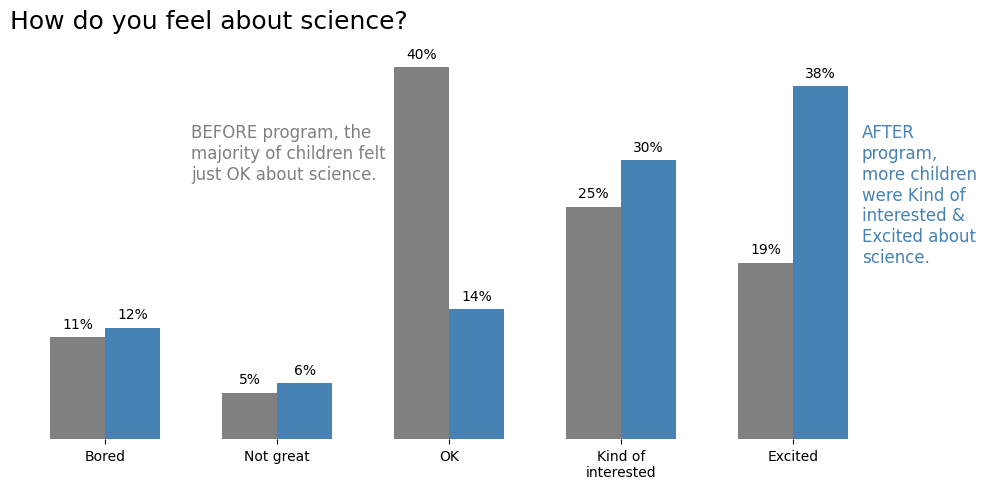

In [85]:
categories = ["Bored", "Not great", "OK", "Kind of\ninterested", "Excited"]
before = [11, 5, 40, 25, 19]
after = [12, 6, 14, 30, 38]
x = np.arange(len(categories))
width = 0.32

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, before, width, color="gray", label="Before")
plt.bar(x + width/2, after, width, color="steelblue", label="After")

# customize the axes and title
plt.xticks(x, categories)
plt.yticks([])
plt.title("How do you feel about science?", loc="left", fontsize=18, pad=15)

# add percentage labels on top of the bars
for i in range(len(categories)):
    plt.text(x[i] - width/2, before[i] + 1, f"{before[i]}%", ha="center", fontsize=10)
    plt.text(x[i] + width/2, after[i] + 1, f"{after[i]}%", ha="center", fontsize=10)

# add annotations to explain the changes
plt.text(4.4, 34,"AFTER\nprogram,\nmore children\nwere Kind of\ninterested &\nExcited about\nscience.",
         color="steelblue",fontsize=12,va="top")

plt.text(0.5, 34,"BEFORE program, the \nmajority of children felt\njust OK about science.",
         color="gray", fontsize=12,va="top")

# remove axes spines for a cleaner look
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()

I chose Figure 0.5 from the Introduction of *Storytelling With Data*.  
I recreated the improved survey results bar chart using Matplotlib.  
The graph compares students' feelings about science before and after the pilot program.  
The bar chart makes the story clearer than the pie charts because it is easier to compare the before and after percentages.  
After the program, more students were “Kind of interested” or “Excited” about science, which supports the message that the pilot program was successful.